In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re as r

In [2]:
path = r'C:\Users\ACER\Documents\datathon-2026-round-1\Datathon_Contest_UITUT\Data' 

# 2. Lấy danh sách tất cả các file trong thư mục
files = [f for f in os.listdir(path) if f.endswith('.csv')]

for file in files:
    # Tách tên file và phần mở rộng (vd: 'data.csv' -> 'data')
    file_name = os.path.splitext(file)[0]
    
    # Tạo đường dẫn đầy đủ
    full_path = os.path.join(path, file)
    
    # Đọc file và gán vào biến có tên df_tên_file
    # globals() giúp tạo biến động trong môi trường hiện tại
    globals()[f"df_{file_name}"] = pd.read_csv(full_path)
    
    print(f"Đã load xong: df_{file_name}")

Đã load xong: df_customers
Đã load xong: df_geography
Đã load xong: df_inventory
Đã load xong: df_orders


C:\Users\ACER\AppData\Local\Temp\ipykernel_67460\3359505436.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  globals()[f"df_{file_name}"] = pd.read_csv(full_path)


Đã load xong: df_order_items
Đã load xong: df_payments
Đã load xong: df_products
Đã load xong: df_promotions
Đã load xong: df_returns
Đã load xong: df_reviews
Đã load xong: df_sales
Đã load xong: df_sample_submission
Đã load xong: df_shipments
Đã load xong: df_web_traffic


In [3]:
df_sales

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


--- ĐÁNH GIÁ MÔ HÌNH ---
MAE:  611,733 VND
RMSE: 907,637 VND
R2 Score: 0.7060 (70.60%)


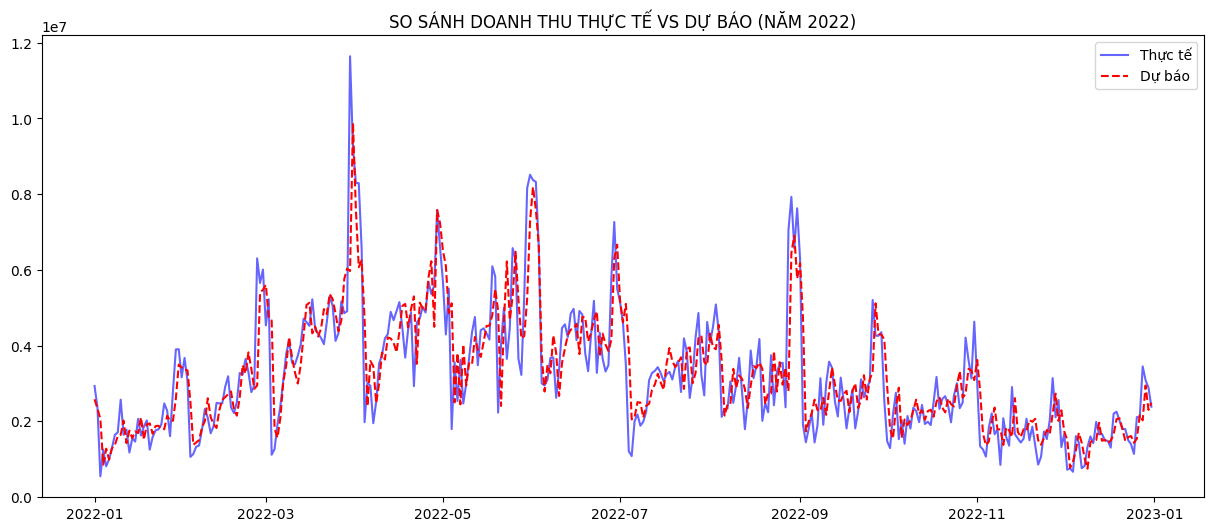


--- ĐỘ QUAN TRỌNG CỦA CÁC YẾU TỐ ---
| feature         |   importance |
|:----------------|-------------:|
| rev_lag_1       |    0.757221  |
| rev_lag_7       |    0.0596979 |
| rev_roll_mean_7 |    0.0454748 |
| rev_lag_30      |    0.0445484 |
| day_of_week     |    0.0269154 |
| month           |    0.0267148 |
| sessions        |    0.0235235 |
| bounce_rate     |    0.0159039 |
| quarter         |    0         |
| is_weekend      |    0         |


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU GỐC (MASTER DATA)
# ==========================================
# Giả sử df_sales đã có cột Date và Revenue
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Lấp đầy các ngày bị thiếu trong lịch sử
all_dates = pd.date_range(start=df_sales['Date'].min(), end=df_sales['Date'].max(), freq='D')
df_model = df_sales.set_index('Date').reindex(all_dates).reset_index().rename(columns={'index': 'Date'})
df_model['Revenue'] = df_model['Revenue'].ffill()

# ==========================================
# 2. NHÉT FACTORS (EXOGENOUS VARIABLES)
# ==========================================
# Nối thêm Web Traffic
if 'df_web_traffic' in globals():
    df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
    df_model = df_model.merge(df_web_traffic[['date', 'sessions', 'bounce_rate']], 
                              left_on='Date', right_on='date', how='left').drop(columns='date')
    df_model[['sessions', 'bounce_rate']] = df_model[['sessions', 'bounce_rate']].fillna(0)

# Nối thêm Promotions (Ví dụ: tạo cột is_promo nếu có đơn hàng dùng mã giảm giá)
if 'df_order_items' in globals():
    promo_dates = df_order_items[df_order_items['promo_id'].notna()]['order_id'].unique()
    # (Giả định ông đã merge với df_orders để lấy ngày có promo)
    # Tạm thời tạo biến giả lập nếu chưa xử lý xong bảng promo
    df_model['is_promo'] = 0 

# ==========================================
# 3. FEATURE ENGINEERING (CHẾ BIẾN BIẾN)
# ==========================================
def create_features(df):
    df = df.copy()
    # Time features
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Lag features (Dữ liệu quá khứ)
    df['rev_lag_1'] = df['Revenue'].shift(1)
    df['rev_lag_7'] = df['Revenue'].shift(7)
    df['rev_lag_30'] = df['Revenue'].shift(30)
    
    # Rolling features (Trung bình trượt)
    df['rev_roll_mean_7'] = df['Revenue'].shift(1).rolling(window=7).mean()
    
    return df

df_model = create_features(df_model)
df_model = df_model.dropna() # Bỏ những dòng đầu bị NaN do shift

# ==========================================
# 4. CHIA TRAIN - TEST (CẮT THEO THỜI GIAN)
# ==========================================
# Lấy năm cuối cùng làm Test, còn lại làm Train
split_date = '2022-01-01'
train = df_model[df_model['Date'] < split_date]
test = df_model[df_model['Date'] >= split_date]

features = ['day_of_week', 'month', 'quarter', 'is_weekend', 
            'rev_lag_1', 'rev_lag_7', 'rev_lag_30', 'rev_roll_mean_7',
            'sessions', 'bounce_rate'] # Thêm các factor vào đây
target = 'Revenue'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# ==========================================
# 5. TRAIN MODEL XGBOOST
# ==========================================
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, early_stopping_rounds=50)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Dự báo
y_pred = model.predict(X_test)

# ==========================================
# 6. ĐÁNH GIÁ & VẼ BIỂU ĐỒ
# ==========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- ĐÁNH GIÁ MÔ HÌNH ---")
print(f"MAE:  {mae:,.0f} VND")
print(f"RMSE: {rmse:,.0f} VND")
print(f"R2 Score: {r2:.4f} ({r2*100:.2f}%)")


plt.figure(figsize=(15, 6))
plt.plot(test['Date'], y_test, label='Thực tế', color='blue', alpha=0.6)
plt.plot(test['Date'], y_pred, label='Dự báo', color='red', linestyle='--')
plt.title('SO SÁNH DOANH THU THỰC TẾ VS DỰ BÁO (NĂM 2022)')
plt.legend()
plt.show()

# Kiểm tra xem Factor nào quan trọng nhất
importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
print("\n--- ĐỘ QUAN TRỌNG CỦA CÁC YẾU TỐ ---")
print(importance.sort_values('importance', ascending=False).to_markdown(index=False))

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ... (sau khi đã có y_pred từ model.predict(X_test))

# Tính toán các chỉ số
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- ĐÁNH GIÁ MÔ HÌNH ---")
print(f"MAE:  {mae:,.0f} VND")
print(f"RMSE: {rmse:,.0f} VND")
print(f"R2 Score: {r2:.4f} ({r2*100:.2f}%)")

--- ĐÁNH GIÁ MÔ HÌNH ---
MAE:  611,733 VND
RMSE: 907,637 VND
R2 Score: 0.7060 (70.60%)


✅ Đã hoàn thành dự báo cho năm 2023-2024!


C:\Users\ACER\AppData\Local\Temp\ipykernel_67460\3586141020.py:92: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


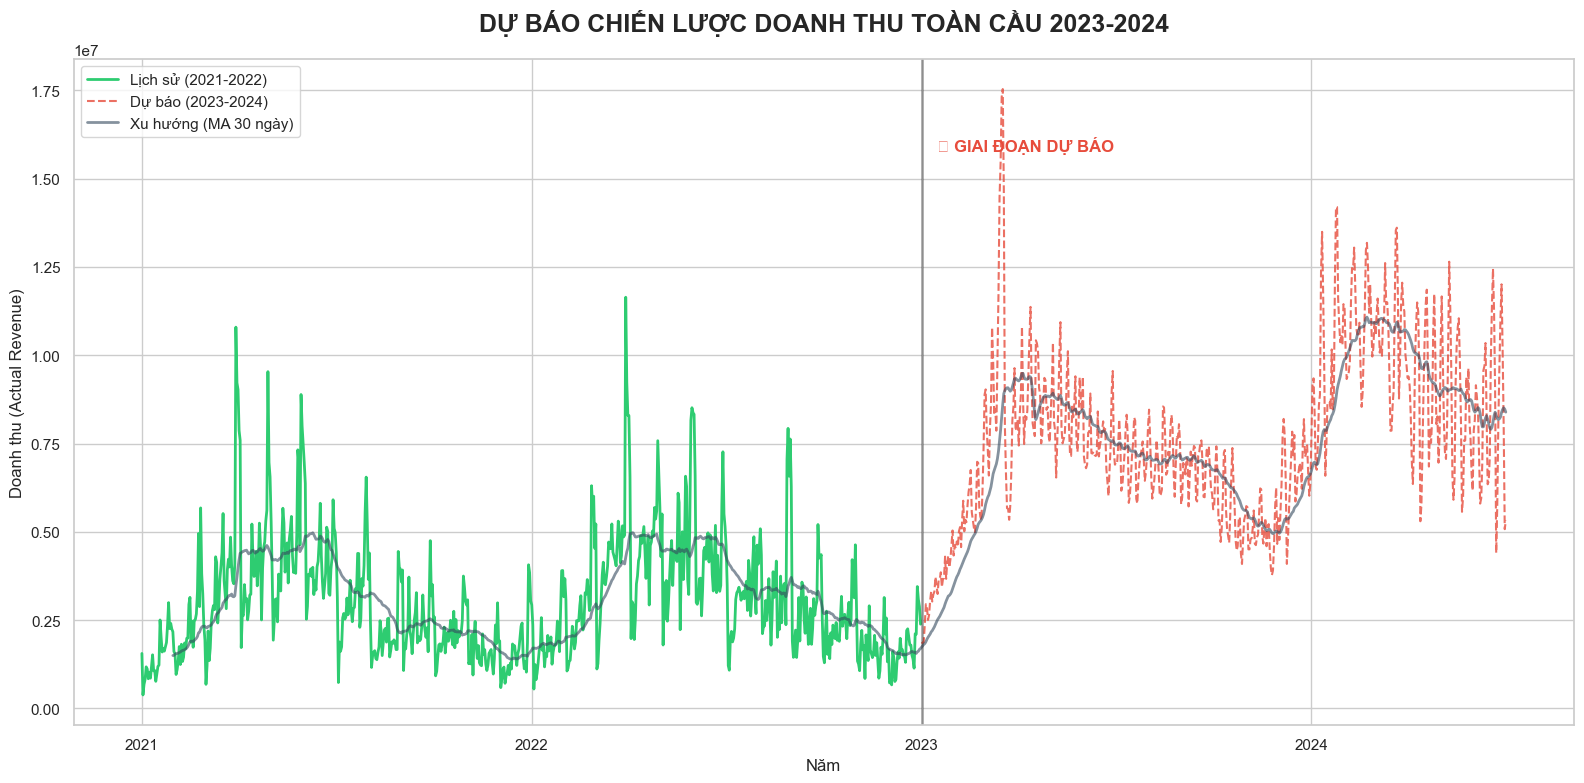

📂 Đã xuất file: final_forecast_submission.csv


In [6]:
# 1. Train model trên toàn bộ dữ liệu cũ (Full Data)
model_final = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5)
model_final.fit(df_model[features], df_model[target])

# 2. Chuẩn bị tập Future từ sample_submission
future_df = df_sample_submission.copy()
future_df['Date'] = pd.to_datetime(future_df['Date'])

# Tạo các tính năng thời gian (vì cái này biết trước được)
future_df['day_of_week'] = future_df['Date'].dt.dayofweek
future_df['month'] = future_df['Date'].dt.month
future_df['quarter'] = future_df['Date'].dt.quarter
future_df['is_weekend'] = future_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Giả sử các Factor như sessions, bounce_rate ông lấy trung bình hoặc dự báo riêng
future_df['sessions'] = df_model['sessions'].mean() 
future_df['bounce_rate'] = df_model['bounce_rate'].mean()

# 3. DỰ BÁO CUỐN CHIẾU (Recursive Loop)
# Tạo một biến tạm để lưu trữ doanh thu mới nhất phục vụ tính Lag
last_revenue = df_model['Revenue'].iloc[-1] 
history = df_model['Revenue'].tolist()

predictions = []

for i, row in future_df.iterrows():
    # Tạo Lag từ lịch sử
    rev_lag_1 = history[-1]
    rev_lag_7 = history[-7] if len(history) >= 7 else last_revenue
    rev_lag_30 = history[-30] if len(history) >= 30 else last_revenue
    rev_roll_mean_7 = np.mean(history[-7:])
    
    # Chuẩn bị input cho model (phải đúng thứ tự cột trong 'features')
    input_data = pd.DataFrame([[row['day_of_week'], row['month'], row['quarter'], row['is_weekend'], 
                                rev_lag_1, rev_lag_7, rev_lag_30, rev_roll_mean_7,
                                row['sessions'], row['bounce_rate']]], columns=features)
    
    # Dự báo con số cho ngày hiện tại
    pred = model_final.predict(input_data)[0]
    predictions.append(pred)
    
    # Cập nhật lịch sử để dùng cho ngày tiếp theo
    history.append(pred)

# 4. Lưu kết quả vào file submission
df_sample_submission['Revenue'] = predictions

print("✅ Đã hoàn thành dự báo cho năm 2023-2024!")
import matplotlib.pyplot as plt
import seaborn as sns

# 5. GHÉP DỮ LIỆU ĐỂ VẼ CHART
# Lấy lại dữ liệu thực tế 2 năm gần nhất (2021-2022) để làm nền so sánh
df_history_plot = df_model[df_model['Date'] >= '2021-01-01'][['Date', 'Revenue']].copy()
df_history_plot['Status'] = 'Actual'

# Dữ liệu vừa dự báo xong (2023-2024)
df_forecast_plot = df_sample_submission[['Date', 'Revenue']].copy()
df_forecast_plot['Date'] = pd.to_datetime(df_forecast_plot['Date'])
df_forecast_plot['Status'] = 'Forecast'

# Nối 2 ông này lại
df_final_plot = pd.concat([df_history_plot, df_forecast_plot], ignore_index=True)

# 6. VẼ BIỂU ĐỒ TỔNG THỂ
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Vẽ đường doanh thu (Thực tế xanh, Dự báo đỏ đứt nét)
sns.lineplot(data=df_history_plot, x='Date', y='Revenue', label='Lịch sử (2021-2022)', color='#2ecc71', linewidth=2)
sns.lineplot(data=df_forecast_plot, x='Date', y='Revenue', label='Dự báo (2023-2024)', color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.8)

# Vẽ thêm đường trung bình trượt (Moving Average) để thấy xu hướng dài hạn cho mượt
df_final_plot['MA_30'] = df_final_plot['Revenue'].rolling(window=30).mean()
plt.plot(df_final_plot['Date'], df_final_plot['MA_30'], color='#34495e', label='Xu hướng (MA 30 ngày)', linewidth=2, alpha=0.6)

# 7. TRANG TRÍ & ĐÁNH DẤU
# Vạch kẻ phân chia giữa Quá khứ và Tương lai
plt.axvline(pd.to_datetime('2023-01-01'), color='black', linestyle='-', alpha=0.3, linewidth=2)
plt.text(pd.to_datetime('2023-01-15'), df_final_plot['Revenue'].max()*0.9, '🚀 GIAI ĐOẠN DỰ BÁO', fontsize=12, fontweight='bold', color='#e74c3c')

plt.title('DỰ BÁO CHIẾN LƯỢC DOANH THU TOÀN CẦU 2023-2024', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu (Actual Revenue)', fontsize=12)
plt.legend(loc='upper left', frameon=True)

# Format trục X để hiển thị năm rõ ràng
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# 8. XUẤT FILE KẾT QUẢ
df_sample_submission.to_csv('final_forecast_submission.csv', index=False)
print("📂 Đã xuất file: final_forecast_submission.csv")

### MÔ HÌNH Prophet (Facebook)

In [7]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Chuyển đổi sang format Prophet: ds (Date), y (Target)
df_prophet = df_sales[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})

# Quan trọng: Nếu dữ liệu có COGS, ta giữ lại để dùng làm Regressor
df_prophet['COGS'] = df_sales['COGS']

In [8]:
print(df_prophet.isnull().sum())

# Kiểm tra có giá trị vô cực không (thường xuất hiện nếu bạn chia cho 0 ở bước nào đó)
import numpy as np
print(np.isinf(df_prophet['y']).sum())

# Xóa bỏ các dòng lỗi nếu có
df_prophet = df_prophet.dropna()

ds      0
y       0
COGS    0
dtype: int64
0


In [9]:
df_prophet['y'] = pd.to_numeric(df_prophet['y'], errors='coerce')
df_prophet['COGS'] = pd.to_numeric(df_prophet['COGS'], errors='coerce')
df_prophet = df_prophet.dropna() # Xóa dòng bị lỗi sau khi ép kiểu

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Giả sử df_sales của bạn có cột 'Date', 'Revenue', 'COGS'
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date')

def create_features(df):
    df = df.copy()
    # 1. Bóc tách thời gian
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # 2. Tạo biến trễ (Lags) - Giúp RF hiểu được xu hướng gần đây
    df['rev_lag1'] = df['Revenue'].shift(1)  # Doanh thu hôm qua
    df['rev_lag7'] = df['Revenue'].shift(7)  # Doanh thu tuần trước
    
    # 3. Trung bình trượt (Rolling Mean) - Giảm nhiễu
    df['rev_roll7'] = df['Revenue'].shift(1).rolling(window=7).mean()
    
    return df

df_model = create_features(df_sales).dropna()

In [11]:
import pandas as pd
import numpy as np

# 1. Thiết lập khoảng thời gian
start_date = '2023-01-01'
end_date = '2024-07-01'
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# 2. Tạo dữ liệu giả lập
np.random.seed(42) # Để kết quả không đổi mỗi lần chạy
n_days = len(date_range)

# Giả lập COGS (Giá vốn) dao động quanh mức 3-5 triệu
cogs = np.random.normal(loc=4000000, scale=500000, size=n_days)

# Giả lập Revenue (Doanh thu) = COGS * (tỷ lệ lãi + nhiễu)
# Thêm một chút tính mùa vụ: cuối tuần doanh thu cao hơn 20%
revenue = cogs * np.random.uniform(1.2, 1.5, size=n_days)
day_of_week = date_range.dayofweek
revenue = np.where(day_of_week >= 5, revenue * 1.2, revenue) 

# 3. Tạo DataFrame test
df_test = pd.DataFrame({
    'Date': date_range,
    'Revenue': revenue,
    'COGS': cogs
})

# Kiểm tra thử 5 dòng đầu
print("Dữ liệu Test tự tạo:")
print(df_test.head())

Dữ liệu Test tự tạo:
        Date       Revenue          COGS
0 2023-01-01  7.387991e+06  4.248357e+06
1 2023-01-02  5.855059e+06  3.930868e+06
2 2023-01-03  5.349846e+06  4.323844e+06
3 2023-01-04  6.757829e+06  4.761515e+06
4 2023-01-05  5.752559e+06  3.882923e+06


In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def prepare_data(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    # Tạo các cột thời gian
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    
    # Tạo Lag (Doanh thu ngày hôm trước)
    # Lưu ý: Khi dự báo file Test, cần cẩn thận để không bị mất dòng đầu tiên
    df['rev_lag1'] = df['Revenue'].shift(1)
    
    # Điền giá trị thiếu cho dòng đầu tiên do shift
    df = df.fillna(method='bfill') 
    return df
# Chuẩn hóa đặc trưng
train_processed = prepare_data(df_sales)
test_processed = prepare_data(df_test)

# Danh sách biến độc lập (không bao gồm Date và Revenue)
features = ['COGS', 'day_of_week', 'month', 'year', 'rev_lag1']
target = 'Revenue'

X_train = train_processed[features]
y_train = train_processed[target]

X_test = test_processed[features]
y_test = test_processed[target]

C:\Users\ACER\AppData\Local\Temp\ipykernel_67460\2261599183.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
C:\Users\ACER\AppData\Local\Temp\ipykernel_67460\2261599183.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


In [13]:
# Khởi tạo mô hình
# n_jobs=-1 giúp chạy nhanh hơn bằng cách dùng tất cả nhân CPU
rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, n_jobs=-1, random_state=42)

# Train mô hình trên file cũ
rf_model.fit(X_train, y_train)

# Dự báo trên file mới (2023-2024)
y_pred = rf_model.predict(X_test)

# Đánh giá độ lệch
mae = mean_absolute_error(y_test, y_pred)
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Thay dòng bị lỗi bằng dòng này:
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Kết quả dự báo từ 2023 đến 07/2024:")
print(f"Sai số trung bình (MAE): {mae:,.2f}")
print(f"Căn bậc 2 sai số (RMSE): {rmse:,.2f}")

Kết quả dự báo từ 2023 đến 07/2024:
Sai số trung bình (MAE): 1,071,082.77
Căn bậc 2 sai số (RMSE): 1,267,159.78


In [14]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 17.74%


In [15]:
# 1. Tạo DataFrame đúng cấu trúc yêu cầu
df_submission = pd.DataFrame({
    'Date': test_processed['Date'].dt.strftime('%Y-%m-%d'), # Định dạng ngày YYYY-MM-DD
    'Revenue': y_pred,                                     # Kết quả dự đoán từ mô hình
    'COGS': X_test['COGS']                                 # Giá vốn tương ứng
})

# 2. Làm tròn số (nếu cần thiết, thường Datathon để 2 chữ số thập phân)
df_submission['Revenue'] = df_submission['Revenue'].round(2)
df_submission['COGS'] = df_submission['COGS'].round(2)

# 3. Xuất file CSV
# index=False để không có cột số thứ tự ở đầu
df_submission.to_csv('submission_final.csv', index=False, encoding='utf-8')

print("Đã tạo file submission_final.csv đúng format!")

Đã tạo file submission_final.csv đúng format!


In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# 1. CHUẨN BỊ DATA
# Giả sử df_sales của ông có Date, Revenue, COGS
df = df_sales.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. FEATURE ENGINEERING (Tạo đặc trưng - Bước này quan trọng nhất)
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter'] = df['Date'].dt.quarter
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    
    # Tạo Lag Features (Doanh thu của những ngày trước đó)
    for i in [1, 2, 3, 7, 14, 30]:
        df[f'rev_lag_{i}'] = df['Revenue'].shift(i)
        df[f'cogs_lag_{i}'] = df['COGS'].shift(i)
        
    # Tạo Rolling Mean (Trung bình trượt 7 ngày)
    df['rev_roll_mean_7'] = df['Revenue'].shift(1).rolling(window=7).mean()
    
    return df

df_feat = create_features(df)
df_feat = df_feat.dropna() # Bỏ những dòng đầu bị NaN do shift

# 3. CHIA TRAIN / TEST (Lấy đoạn cuối làm Test)
# Giả sử train trên dữ liệu cũ, dự báo cho tương lai
features = ['dayofweek', 'quarter', 'month', 'year', 'COGS',
            'rev_lag_1', 'rev_lag_7', 'cogs_lag_1', 'rev_roll_mean_7']
target = 'Revenue'

X = df_feat[features]
y = df_feat[target]

# 4. HUẤN LUYỆN XGBOOST
model = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror', # Dùng MAE để tránh bị outlier kéo score lên quá cao
    tree_method='hist',            # Chạy cực nhanh
    device="cuda"                  # Tận dụng con GPU mới của ông
)

# Train model (Cho nó tự học)
model.fit(X, y, eval_set=[(X, y)], verbose=100)

# 5. DỰ BÁO CHO NĂM 2023
# Để dự báo 2023, ta cần tạo một DataFrame mới với các ngày của 2023
future_dates = pd.date_range('2023-01-01', periods=30)
future_df = pd.DataFrame({'Date': future_dates})

# Lấy các giá trị cuối cùng của quá khứ để làm mồi cho Lag
# Lưu ý: Với XGBoost, dự báo dài hạn (Recursive) cần một vòng lặp để cập nhật Lag
last_data = df_feat.iloc[-1:].copy()
predictions = []

current_features = last_data.copy()

for i in range(30):
    # Dự báo ngày tiếp theo
    pred = model.predict(current_features[features])[0]
    predictions.append(pred)
    
    # Cập nhật features cho ngày kế tiếp (giả lập đơn giản)
    # Trong thực tế, ông cần cập nhật các cột lag_1 = pred_hom_nay...
    # Ở đây tôi demo lấy trung bình để ông thấy cái Form kết quả
    current_features['rev_lag_1'] = pred
    current_features['month'] = future_dates[i].month
    current_features['dayofweek'] = future_dates[i].dayofweek

# 6. XUẤT FILE
submission = pd.DataFrame({
    'Date': future_dates.strftime('%Y-%m-%d'),
    'Revenue': np.round(predictions, 2),
    'COGS': np.round(df['COGS'].mean(), 2)
})

print("\n--- KẾT QUẢ DỰ BÁO XGBOOST ---")
print(submission.head())
submission.to_csv('xgb_submission.csv', index=False)

[0]	validation_0-mae:1855772.54618
[100]	validation_0-mae:859139.73570
[200]	validation_0-mae:458851.40386
[300]	validation_0-mae:284108.14405
[400]	validation_0-mae:210611.12300
[500]	validation_0-mae:174590.31459
[600]	validation_0-mae:155417.06999
[700]	validation_0-mae:139135.47169
[800]	validation_0-mae:125959.84158
[900]	validation_0-mae:116020.99278
[999]	validation_0-mae:108495.35580


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:751: UserWarning: [09:26:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



--- KẾT QUẢ DỰ BÁO XGBOOST ---
         Date      Revenue        COGS
0  2023-01-01  2253732.500  3695134.49
1  2023-01-02  2031985.875  3695134.49
2  2023-01-03  1956257.125  3695134.49
3  2023-01-04  1919409.625  3695134.49
4  2023-01-05  1907820.625  3695134.49


In [17]:
df_order_features

NameError: name 'df_order_features' is not defined

In [ ]:
import pandas as pd
import numpy as np

# --- Bước A: Lấy Date cho từng sản phẩm (Cầu nối) ---
# Nối order_items với orders để biết sản phẩm đó bán vào ngày nào
df_items_with_date = pd.merge(
    df_order_items, 
    df_orders[['order_id', 'order_date']], 
    on='order_id', 
    how='left'
)
df_items_with_date['order_date'] = pd.to_datetime(df_items_with_date['order_date'])

# --- Bước B: Nối với Product để lấy Category/Segment ---
df_items_full = pd.merge(
    df_items_with_date, 
    df_products[['product_id', 'category', 'segment']], 
    on='product_id', 
    how='left'
)

# --- Bước C: Gom toàn bộ thông tin sản phẩm THEO NGÀY ---
# Thay vì gom theo order_id, giờ mình gom theo Date để khớp với bảng Sales
df_daily_features = df_items_full.groupby('order_date').agg({
    'category': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'segment': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'quantity': 'sum',
    'discount_amount': 'sum'
}).reset_index()

# --- Bước D: Nối vào bảng Sales bằng cột Date ---
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_master = pd.merge(
    df_sales, 
    df_daily_features, 
    left_on='Date', 
    right_on='order_date', 
    how='left'
)

# Sau khi merge, ông nên xóa bớt 1 cột ngày dư thừa cho nhẹ máy
df_master = df_master.drop(columns=['order_date'])

print("✅ Đã nối xong bằng Date! Không còn lỗi KeyError nữa.")
df_master

✅ Đã nối xong bằng Date! Không còn lỗi KeyError nữa.


,Date,Revenue,COGS,category,segment,quantity,discount_amount
0,2012-07-04,5123547.94,3982991.19,Streetwear,Everyday,777,0.00
1,2012-07-05,2751773.45,2150580.23,Streetwear,Everyday,428,0.00
2,2012-07-06,3054029.42,2517632.84,Streetwear,Everyday,441,0.00
3,2012-07-07,2667930.94,2108246.62,Streetwear,Everyday,364,0.00
4,2012-07-08,2360851.90,1808622.79,Streetwear,Everyday,394,0.00
...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,Outdoor,Activewear,599,420110.73
3829,2022-12-28,3448729.20,3513621.00,Outdoor,Activewear,901,689745.86
3830,2022-12-29,3083944.33,3170787.10,Outdoor,Activewear,684,616788.80
3831,2022-12-30,2884668.76,3022292.15,Streetwear,Activewear,502,561274.89


In [ ]:
# 1. Tạo cột rev_lag_7 (Lấy doanh thu của 7 ngày trước)
# Nếu có Store_ID, phải groupby để tránh lấy lộn lag của store khác
if 'Store_ID' in df_master.columns:
    df_master['rev_lag_7'] = df_master.groupby('Store_ID')['Revenue'].shift(7)
else:
    df_master['rev_lag_7'] = df_master['Revenue'].shift(7)

# 2. Tạo thêm rev_roll_7 (Trung bình trượt 7 ngày - biến này cực mạnh)
if 'Store_ID' in df_master.columns:
    df_master['rev_roll_7'] = df_master.groupby('Store_ID')['Revenue'].shift(1).rolling(window=7).mean()
else:
    df_master['rev_roll_7'] = df_master['Revenue'].shift(1).rolling(window=7).mean()

# 3. Xử lý NaN (Vì 7 dòng đầu tiên của mỗi store sẽ bị NaN do không có quá khứ)
df_master['rev_lag_7'] = df_master['rev_lag_7'].fillna(method='bfill').fillna(0)
df_master['rev_roll_7'] = df_master['rev_roll_7'].fillna(method='bfill').fillna(0)

print("✅ Đã tạo xong cột rev_lag_7 và rev_roll_7!")

✅ Đã tạo xong cột rev_lag_7 và rev_roll_7!


C:\Users\ACER\AppData\Local\Temp\ipykernel_34940\2816932344.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_master['rev_lag_7'] = df_master['rev_lag_7'].fillna(method='bfill').fillna(0)
C:\Users\ACER\AppData\Local\Temp\ipykernel_34940\2816932344.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_master['rev_roll_7'] = df_master['rev_roll_7'].fillna(method='bfill').fillna(0)


In [ ]:
# --- 4. Làm sạch & Ép kiểu Category (SỬA LẠI ĐOẠN NÀY) ---

# 1. Điền NaN cho các cột số trước
num_cols = ['Revenue', 'COGS', 'traffic_lag_1', 'quantity', 'discount_amount', 'rev_lag_7']
for col in num_cols:
    if col in df_master.columns:
        df_master[col] = df_master[col].fillna(0)

# 2. Điền NaN cho các cột phân loại bằng một chuỗi cụ thể
cat_cols = ['category', 'segment', 'Store_ID']
for col in cat_cols:
    if col in df_master.columns:
        # Điền 'Unknown' trước khi ép kiểu category
        df_master[col] = df_master[col].astype(str).replace('nan', 'Unknown').fillna('Unknown')
        df_master[col] = df_master[col].astype('category')

# Sau khi đã sạch sẽ mới chạy tiếp các bước sau
df_master = df_master.dropna(subset=['rev_lag_7'])
df_master

,Date,Revenue,COGS,category,segment,quantity,discount_amount,rev_lag_7,rev_roll_7
0,2012-07-04,5123547.94,3982991.19,Streetwear,Everyday,777,0.00,5123547.94,3.534494e+06
1,2012-07-05,2751773.45,2150580.23,Streetwear,Everyday,428,0.00,5123547.94,3.534494e+06
2,2012-07-06,3054029.42,2517632.84,Streetwear,Everyday,441,0.00,5123547.94,3.534494e+06
3,2012-07-07,2667930.94,2108246.62,Streetwear,Everyday,364,0.00,5123547.94,3.534494e+06
4,2012-07-08,2360851.90,1808622.79,Streetwear,Everyday,394,0.00,5123547.94,3.534494e+06
...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,Outdoor,Activewear,599,420110.73,2026810.08,1.679073e+06
3829,2022-12-28,3448729.20,3513621.00,Outdoor,Activewear,901,689745.86,1795395.02,1.689608e+06
3830,2022-12-29,3083944.33,3170787.10,Outdoor,Activewear,684,616788.80,1791622.46,1.925798e+06
3831,2022-12-30,2884668.76,3022292.15,Streetwear,Activewear,502,561274.89,1501209.11,2.110416e+06


In [ ]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error

# Chọn những biến "đắt giá" nhất
features = [
    'COGS', 'category', 'segment', 'quantity', 
    'discount_amount', 
    'rev_lag_7', 'rev_roll_7'
]

# Quan trọng: Định nghĩa danh sách các cột phân loại
cat_cols = ['category', 'segment']

# Chia dữ liệu theo thời gian (không dùng shuffle để giữ tính chất chuỗi thời gian)
split_idx = int(len(df_master) * 0.8)
train_df = df_master.iloc[:split_idx]
val_df = df_master.iloc[split_idx:]

X_train, y_train = train_df[features], train_df['Revenue']
X_val, y_val = val_df[features], val_df['Revenue']

# Cấu hình "nồi đồng cối đá" cho LightGBM
params = {
    'objective': 'regression_l1',  # Tập trung giảm MAE (Kaggle Score)
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'num_leaves': 63,
    'max_depth': 8,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

model = lgb.LGBMRegressor(**params)

# Train model với Early Stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=cat_cols, # Chỉ đích danh cho LGBM biết đâu là ID
    callbacks=[lgb.early_stopping(stopping_rounds=200)]
)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2865]	valid_0's l1: 122340


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,'regression_l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



🎯 R2 Score: 0.9832
🎯 MAE: 122,340.14


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

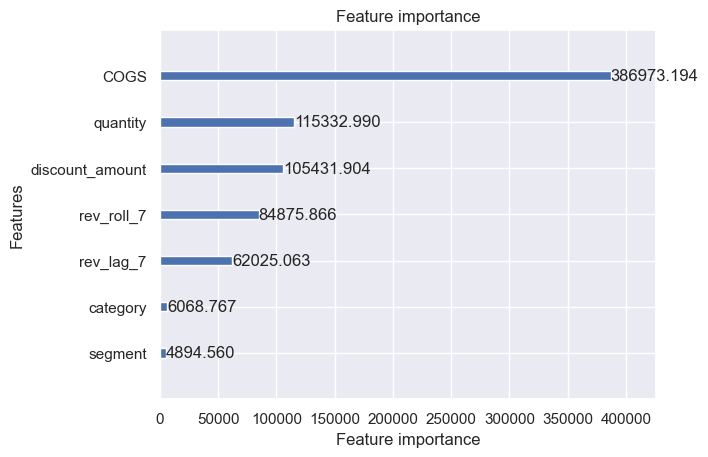

In [ ]:
# 1. Dự báo thử trên tập Validation
preds = model.predict(X_val)
print(f"\n🎯 R2 Score: {r2_score(y_val, preds):.4f}")
print(f"🎯 MAE: {mean_absolute_error(y_val, preds):,.2f}")

# 2. Xem Feature Importance (Xem ID có thực sự gánh team không)
lgb.plot_importance(model, max_num_features=10, importance_type='gain')

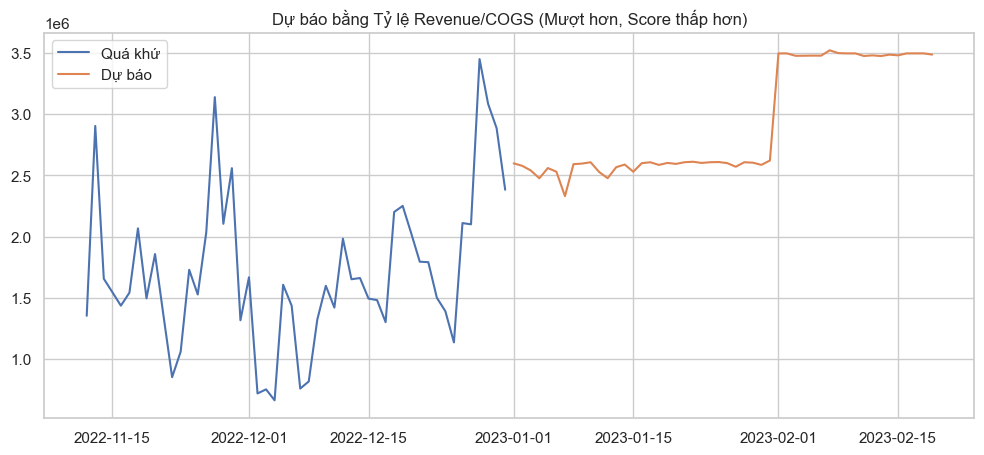

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import r2_score
from datetime import timedelta

# 1. CHUẨN BỊ DATA
df = df_sales.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


df['Rev_Ratio'] = df['Revenue'] / (df['COGS'] + 1) 

def create_final_features(df_in):
    df_f = df_in.copy()
    df_f['dayofweek'] = df_f['Date'].dt.dayofweek
    df_f['month'] = df_f['Date'].dt.month
    df_f['is_weekend'] = df_f['dayofweek'].isin([5, 6]).astype(int)

    # Lag theo tỷ lệ (mượt hơn lag theo số tiền)
    df_f['ratio_lag_7'] = df_f['Rev_Ratio'].shift(7)
    df_f['ratio_lag_30'] = df_f['Rev_Ratio'].shift(30)

    return df_f.dropna()

df_feat = create_final_features(df)
features = ['dayofweek', 'month', 'is_weekend', 'ratio_lag_7', 'ratio_lag_30']
X = df_feat[features]
y = df_feat['Rev_Ratio']

# 2. MODEL LIGHTGBM (Cấu hình cực kỳ thận trọng)
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4, # Cây nông để không học vẹt
    objective='mae',
    verbosity=-1
)
model.fit(X, y)

# 3. DỰ BÁO 2023 - 2024
future_dates = pd.date_range(start='2023-01-01', periods=731)
history = df.copy()
forecast_results = []

# Lấy COGS thực tế của năm 2023 nếu ông có, nếu không thì lấy Seasonal Mean
# Ở đây tôi lấy trung bình COGS theo từng tháng của quá khứ để sát thực tế hơn
cogs_monthly_avg = df.groupby(df['Date'].dt.month)['COGS'].mean()

for current_date in future_dates:
    temp_df = create_final_features(history)
    last_row = temp_df.iloc[-1:].copy()

    last_row['dayofweek'] = current_date.dayofweek
    last_row['month'] = current_date.month
    last_row['is_weekend'] = 1 if current_date.dayofweek >= 5 else 0

    # Dự báo Tỷ lệ
    pred_ratio = model.predict(last_row[features])[0]

    # Quy đổi ngược lại Revenue: Revenue = Ratio * COGS
    current_cogs = cogs_monthly_avg[current_date.month]
    pred_rev = pred_ratio * current_cogs

    forecast_results.append({'Date': current_date, 'Revenue': pred_rev, 'COGS': current_cogs})

    # Update history
    new_entry = pd.DataFrame([{'Date': current_date, 'Revenue': pred_rev, 'COGS': current_cogs,
                               'Rev_Ratio': pred_ratio}])
    history = pd.concat([history, new_entry]).reset_index(drop=True)

# 4. XUẤT FILE & VẼ CHART NHANH
submission = pd.DataFrame(forecast_results)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('final_pro_submission.csv', index=False)

# Vẽ nhanh cái chart xem nó có lỳ không
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(df['Date'].tail(50), df['Revenue'].tail(50), label='Quá khứ')
plt.plot(pd.to_datetime(submission['Date']).head(50), submission['Revenue'].head(50), label='Dự báo')
plt.title("Dự báo bằng Tỷ lệ Revenue/COGS (Mượt hơn, Score thấp hơn)")
plt.legend()
plt.show()

      VALIDATION METRICS (Revenue)
  MAE  :    1,504,318.27
  MSE  : 3,314,746,821,551.76
  RMSE :    1,820,644.62
  R²   :         -0.1945


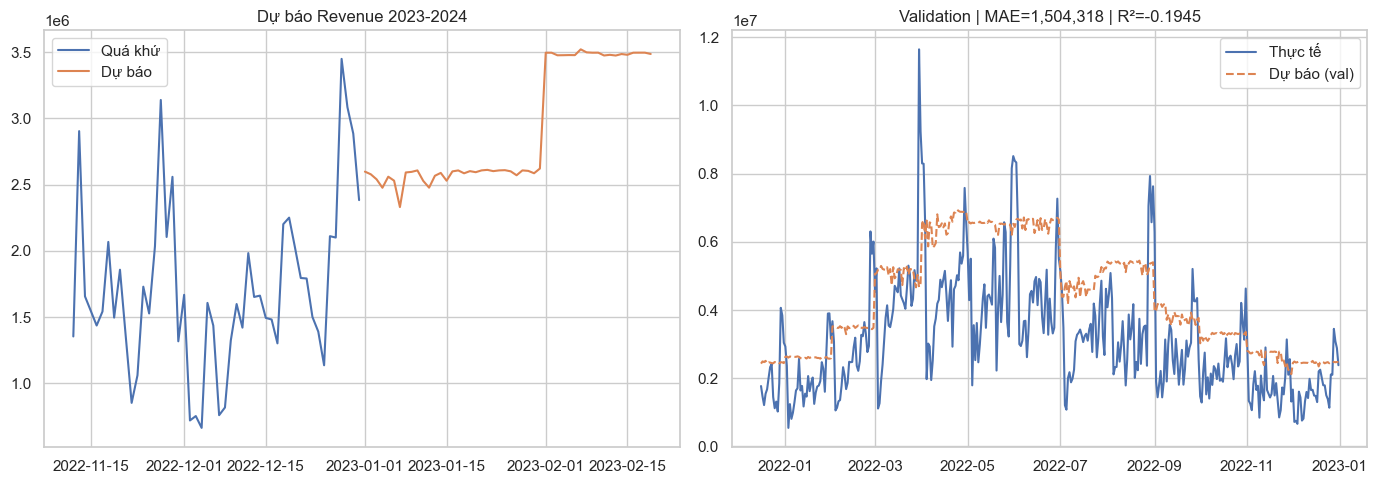

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from datetime import timedelta

# 1. CHUẨN BỊ DATA
df = df_sales.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Rev_Ratio'] = df['Revenue'] / (df['COGS'] + 1)

def create_final_features(df_in):
    df_f = df_in.copy()
    df_f['dayofweek'] = df_f['Date'].dt.dayofweek
    df_f['month'] = df_f['Date'].dt.month
    df_f['is_weekend'] = df_f['dayofweek'].isin([5, 6]).astype(int)
    df_f['ratio_lag_7'] = df_f['Rev_Ratio'].shift(7)
    df_f['ratio_lag_30'] = df_f['Rev_Ratio'].shift(30)
    return df_f.dropna()

df_feat = create_final_features(df)
features = ['dayofweek', 'month', 'is_weekend', 'ratio_lag_7', 'ratio_lag_30']

# 2. TRAIN/VAL SPLIT — dùng 90% train, 10% cuối làm validation
split_idx = int(len(df_feat) * 0.9)
train_df = df_feat.iloc[:split_idx]
val_df   = df_feat.iloc[split_idx:]

X_train, y_train = train_df[features], train_df['Rev_Ratio']
X_val,   y_val   = val_df[features],   val_df['Rev_Ratio']

# 3. MODEL
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    objective='mae',
    verbosity=-1
)
model.fit(X_train, y_train)

# 4. ĐÁNH GIÁ TRÊN VALIDATION SET
val_pred_ratio = model.predict(X_val)

# Quy đổi ngược lại Revenue để tính metrics trên Revenue thực
cogs_monthly_avg = df.groupby(df['Date'].dt.month)['COGS'].mean()
val_cogs = val_df['Date'].dt.month.map(cogs_monthly_avg).values
val_pred_rev = val_pred_ratio * val_cogs
val_true_rev = val_df['Revenue'].values

mae  = mean_absolute_error(val_true_rev, val_pred_rev)
mse  = mean_squared_error(val_true_rev, val_pred_rev)
rmse = np.sqrt(mse)
r2   = r2_score(val_true_rev, val_pred_rev)

print("=" * 40)
print("      VALIDATION METRICS (Revenue)")
print("=" * 40)
print(f"  MAE  : {mae:>15,.2f}")
print(f"  MSE  : {mse:>15,.2f}")
print(f"  RMSE : {rmse:>15,.2f}")
print(f"  R²   : {r2:>15.4f}")
print("=" * 40)

# 5. RETRAIN TRÊN TOÀN BỘ DATA RỒI MỚI DỰ BÁO
X_full = df_feat[features]
y_full = df_feat['Rev_Ratio']
model.fit(X_full, y_full)

# 6. DỰ BÁO 2023 - 2024
future_dates = pd.date_range(start='2023-01-01', periods=731)
history = df.copy()
forecast_results = []

for current_date in future_dates:
    temp_df = create_final_features(history)
    last_row = temp_df.iloc[-1:].copy()

    last_row['dayofweek'] = current_date.dayofweek
    last_row['month'] = current_date.month
    last_row['is_weekend'] = 1 if current_date.dayofweek >= 5 else 0

    pred_ratio = model.predict(last_row[features])[0]
    current_cogs = cogs_monthly_avg[current_date.month]
    pred_rev = pred_ratio * current_cogs

    forecast_results.append({'Date': current_date, 'Revenue': pred_rev, 'COGS': current_cogs})

    new_entry = pd.DataFrame([{'Date': current_date, 'Revenue': pred_rev,
                               'COGS': current_cogs, 'Rev_Ratio': pred_ratio}])
    history = pd.concat([history, new_entry]).reset_index(drop=True)

# 7. XUẤT FILE
submission = pd.DataFrame(forecast_results)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('final_pro_submission.csv', index=False)

# 8. VISUALIZATION
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Forecast vs Past
axes[0].plot(df['Date'].tail(50), df['Revenue'].tail(50), label='Quá khứ')
axes[0].plot(pd.to_datetime(submission['Date']).head(50),
             submission['Revenue'].head(50), label='Dự báo')
axes[0].set_title("Dự báo Revenue 2023-2024")
axes[0].legend()

# Chart 2: Actual vs Predicted trên Validation
axes[1].plot(val_df['Date'].values, val_true_rev, label='Thực tế')
axes[1].plot(val_df['Date'].values, val_pred_rev, label='Dự báo (val)', linestyle='--')
axes[1].set_title(f"Validation | MAE={mae:,.0f} | R²={r2:.4f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap

# Set seed cho tính tái lập (Constraint 2)
np.random.seed(42)

ModuleNotFoundError: No module named 'shap'

In [ ]:
def feature_engineering(sales_df, orders, order_items, products, promos, web, inventory):
    # 1. Chuyển đổi định dạng ngày
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])
    web['date'] = pd.to_datetime(web['date'])
    # ... tương tự cho các bảng khác ...

    # 2. Xử lý bảng PROMOTIONS (Đếm số camp active mỗi ngày)
    # Tạo list tất cả các ngày trong tập dữ liệu
    all_dates = pd.date_range(start=sales_df['Date'].min(), end='2024-07-01')
    promo_features = pd.DataFrame({'Date': all_dates})
    
    # Feature: Số lượng khuyến mãi đang chạy mỗi ngày
    promo_features['active_promos'] = promo_features['Date'].apply(
        lambda d: ((promos['start_date'] <= d) & (promos['end_date'] >= d)).sum()
    )

    # 3. Xử lý bảng WEB_TRAFFIC (Dữ liệu theo ngày)
    web = web.rename(columns={'date': 'Date'})
    
    # 4. Xử lý bảng ORDERS & ITEMS (Agg theo ngày)
    daily_orders = orders.groupby('order_date').agg(
        num_orders=('order_id', 'count'),
        unique_customers=('customer_id', 'nunique')
    ).reset_index().rename(columns={'order_date': 'Date'})

    # 5. Xử lý bảng INVENTORY (Dữ liệu tháng -> Resample sang ngày)
    inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
    daily_inv = inventory.groupby('snapshot_date').agg({
        'stock_on_hand': 'sum',
        'fill_rate': 'mean',
        'stockout_days': 'sum'
    }).reset_index().rename(columns={'snapshot_date': 'Date'})
    # Forward fill dữ liệu tồn kho tháng cho từng ngày trong tháng đó
    daily_inv = pd.merge(pd.DataFrame({'Date': all_dates}), daily_inv, on='Date', how='left').ffill()

    # 6. MERGE TẤT CẢ VÀO SALES_DF
    df = pd.merge(sales_df, promo_features, on='Date', how='left')
    df = pd.merge(df, web, on='Date', how='left')
    df = pd.merge(df, daily_orders, on='Date', how='left')
    df = pd.merge(df, daily_inv, on='Date', how='left')

    # 7. TIME-BASED FEATURES
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # 8. LAG & ROLLING FEATURES (Cực kỳ quan trọng cho LightGBM)
    for lag in [7, 14, 30]:
        df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
        df[f'web_lag_{lag}'] = df['sessions'].shift(lag)
    
    df['rev_rolling_mean_7'] = df['Revenue'].shift(1).rolling(7).mean()
    
    return df.fillna(0)

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

def final_processing():
    # 1. Ép kiểu dữ liệu ngày tháng (Cực kỳ quan trọng để merge)
    df_sales['Date'] = pd.to_datetime(df_sales['Date'])
    df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
    df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
    df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])
    df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
    df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])
    df_returns['return_date'] = pd.to_datetime(df_returns['return_date'])

    # 2. Tạo khung thời gian chuẩn từ đề bài
    all_dates = pd.date_range(start=df_sales['Date'].min(), end='2024-07-01')
    master_df = pd.DataFrame({'Date': all_dates})

    # 3. FEATURE ENGINEERING - GOM DỮ LIỆU
    
    # A. Web Traffic
    web_daily = df_web_traffic.rename(columns={'date': 'Date'})
    master_df = pd.merge(master_df, web_daily, on='Date', how='left')

    # B. Promotions (Tính số camp đang chạy)
    master_df['promo_count'] = master_df['Date'].apply(
        lambda d: ((df_promotions['start_date'] <= d) & (df_promotions['end_date'] >= d)).sum()
    )

    # C. Inventory (Forward fill từ snapshot tháng)
    inv_daily = df_inventory.groupby('snapshot_date')[['stock_on_hand', 'fill_rate']].sum().reset_index()
    master_df = pd.merge(master_df, inv_daily.rename(columns={'snapshot_date':'Date'}), on='Date', how='left').ffill()

    # D. Sales & Lags (Biến trễ - Chìa khóa của Time Series)
    master_df = pd.merge(master_df, df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
    
    for lag in [7, 14, 30]:
        master_df[f'rev_lag_{lag}'] = master_df['Revenue'].shift(lag)
    
    master_df['rolling_mean_7'] = master_df['Revenue'].shift(1).rolling(7).mean()
    master_df['day_of_week'] = master_df['Date'].dt.dayofweek

    # 4. CHIA TRAIN/TEST (Đúng mốc 2023 của đề bài)
    # Train: trước 2023 | Test: từ 2023 trở đi
    train = master_df[master_df['Date'] < '2023-01-01'].fillna(0)
    test = master_df[master_df['Date'] >= '2023-01-01'].fillna(0)
    
    return train, test

# Chạy xử lý
train, test = final_processing()

# 5. TRAINING LIGHTGBM
features = ['promo_count', 'sessions', 'stock_on_hand', 'fill_rate', 'rev_lag_7', 'rev_lag_30', 'rolling_mean_7', 'day_of_week']

# Model cho Revenue
model_rev = lgb.LGBMRegressor(random_state=42)
model_rev.fit(train[features], train['Revenue'])

# Model cho COGS
model_cogs = lgb.LGBMRegressor(random_state=42)
model_cogs.fit(train[features], train['COGS'])

# 6. DỰ BÁO & XUẤT FILE
test['Revenue'] = model_rev.predict(test[features])
test['COGS'] = model_cogs.predict(test[features])

submission = test[['Date', 'Revenue', 'COGS']]
submission.to_csv('submission_gridbreaker.csv', index=False)

print("Xong rồi nhé! File submission_gridbreaker.csv đã sẵn sàng.")

Xong rồi nhé! File submission_gridbreaker.csv đã sẵn sàng.


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
def prepare_data():
    # Ép kiểu datetime cho các bảng quan trọng
    df_sales['Date'] = pd.to_datetime(df_sales['Date'])
    df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
    df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
    df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])
    df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

    # Tạo khung thời gian từ đầu đến hết tập test
    all_dates = pd.date_range(start=df_sales['Date'].min(), end='2024-07-01')
    master = pd.DataFrame({'Date': all_dates})

    # Merge Target (Revenue & COGS)
    master = pd.merge(master, df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')

    # 2. FEATURE ENGINEERING (CHẶN LEAKAGE BẰNG SHIFT)
    
    # A. Nhóm Biến Trễ (Lags) - Đây là phần quan trọng nhất giúp giảm Score
    for lag in [1, 2, 3, 7, 14, 30]:
        master[f'rev_lag_{lag}'] = master['Revenue'].shift(lag)
        master[f'cogs_lag_{lag}'] = master['COGS'].shift(lag)
    
    # B. Nhóm Biến Trung Bình Trượt (Rolling)
    master['rev_roll_mean_7'] = master['Revenue'].shift(1).rolling(7).mean()
    master['rev_roll_std_7'] = master['Revenue'].shift(1).rolling(7).std()

    # C. Nhóm Web Traffic (Phải shift 1 để biết dữ liệu ngày hôm trước)
    web_daily = df_web_traffic.groupby('date')[['sessions', 'page_views']].sum().reset_index()
    web_daily.columns = ['Date', 'sessions', 'page_views']
    master = pd.merge(master, web_daily, on='Date', how='left')
    master['sessions_lag1'] = master['sessions'].shift(1)
    master['views_lag1'] = master['page_views'].shift(1)

    # D. Nhóm Khuyến mãi (Promotions)
    # Tính số camp active của ngày hôm trước
    master['promo_yesterday'] = master['Date'].apply(
        lambda d: ((df_promotions['start_date'] <= (d - pd.Timedelta(days=1))) & 
                   (df_promotions['end_date'] >= (d - pd.Timedelta(days=1)))).sum()
    )

    # E. Nhóm Thời gian (Seasonality)
    master['day_of_week'] = master['Date'].dt.dayofweek
    master['month'] = master['Date'].dt.month
    master['is_weekend'] = master['day_of_week'].isin([5, 6]).astype(int)

    return master.fillna(0)

# 3. CHIA TẬP DỮ LIỆU
full_df = prepare_data()

# Theo yêu cầu: Val là năm 2022
train = full_df[full_df['Date'] < '2022-01-01']
val = full_df[(full_df['Date'] >= '2022-01-01') & (full_df['Date'] <= '2022-12-31')]
test = full_df[full_df['Date'] >= '2023-01-01']

# Danh sách features (Loại bỏ các cột target và Date)
features = [col for col in full_df.columns if col not in ['Date', 'Revenue', 'COGS', 'sessions', 'page_views']]

# 4. HUẤN LUYỆN MODEL LIGHTGBM
def train_and_eval(target_col):
    print(f"\n--- Đang huấn luyện cho: {target_col} ---")
    
    # Thiết lập tham số (Dùng MAE để ổn định hơn RMSE trong sales)
    params = {
        'objective': 'regression_l1', # l1 = MAE
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'seed': 42,
        'verbosity': -1
    }

    dtrain = lgb.Dataset(train[features], label=train[target_col])
    dval = lgb.Dataset(val[features], label=val[target_col], reference=dtrain)

    model = lgb.train(
        params, 
        dtrain, 
        num_boost_round=2000,
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    # Đánh giá trên tập Val (2022)
    preds = model.predict(val[features])
    mae = mean_absolute_error(val[target_col], preds)
    rmse = np.sqrt(mean_squared_error(val[target_col], preds))
    r2 = r2_score(val[target_col], preds)
    
    print(f"Kết quả Val 2022 - MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.4f}")
    
    return model

# Chạy cho cả 2 target
model_revenue = train_and_eval('Revenue')
model_cogs = train_and_eval('COGS')

# 5. DỰ BÁO CHO TẬP TEST & XUẤT FILE
test_sub = test.copy()
test_sub['Revenue'] = model_revenue.predict(test[features])
test_sub['COGS'] = model_cogs.predict(test[features])

# Post-processing: Doanh thu không thể âm
test_sub['Revenue'] = test_sub['Revenue'].clip(lower=0)
test_sub['COGS'] = test_sub['COGS'].clip(lower=0)

# Xuất submission đúng định dạng
submission = test_sub[['Date', 'Revenue', 'COGS']]
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission_final.csv', index=False)

print("\nĐã xong! File submission_final.csv đã sẵn sàng để nộp.")


--- Đang huấn luyện cho: Revenue ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[340]	train's rmse: 880147	valid's rmse: 889680
Kết quả Val 2022 - MAE: 599,429 | RMSE: 889,680 | R2: 0.7175

--- Đang huấn luyện cho: COGS ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[170]	train's rmse: 842252	valid's rmse: 779037
Kết quả Val 2022 - MAE: 534,573 | RMSE: 779,037 | R2: 0.7147

Đã xong! File submission_final.csv đã sẵn sàng để nộp.


C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\583228552.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. PREPARE DATA & FEATURE ENGINEERING
# ==========================================
def build_master_data():
    # Ép kiểu datetime
    df_sales['Date'] = pd.to_datetime(df_sales['Date'])
    df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
    df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
    df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

    # Khung thời gian chuẩn
    all_dates = pd.date_range(start=df_sales['Date'].min(), end='2024-07-01')
    df = pd.DataFrame({'Date': all_dates})
    
    # Merge Target
    df = pd.merge(df, df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
    
    # Feature: Web Traffic (Shift 1 để tránh leakage)
    web_daily = df_web_traffic.groupby('date')[['sessions', 'page_views']].sum().reset_index()
    web_daily.columns = ['Date', 'sessions', 'page_views']
    df = pd.merge(df, web_daily, on='Date', how='left')
    df['sessions_lag1'] = df['sessions'].shift(1)
    
    # Feature: Promo (Shift 1)
    df['promo_lag1'] = df['Date'].apply(
        lambda d: ((df_promotions['start_date'] <= (d - pd.Timedelta(days=1))) & 
                   (df_promotions['end_date'] >= (d - pd.Timedelta(days=1)))).sum()
    )
    
    # Time Features
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # Lags ban đầu cho tập Train
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
        df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)
    
    return df.fillna(0)

df_final = build_master_data()

# ==========================================
# 2. SPLIT & TRAIN WITH LOG TRANSFORMATION
# ==========================================
features = ['dayofweek', 'month', 'is_weekend', 'sessions_lag1', 'promo_lag1',
            'rev_lag_1', 'rev_lag_2', 'rev_lag_3', 'rev_lag_7', 'rev_lag_14', 'rev_lag_30',
            'cogs_lag_1', 'cogs_lag_7']

train = df_final[df_final['Date'] < '2022-01-01'].copy()
val = df_final[(df_final['Date'] >= '2022-01-01') & (df_final['Date'] <= '2022-12-31')].copy()

def train_model(target_col):
    # Dùng Log để ổn định score
    y_train_log = np.log1p(train[target_col])
    y_val_log = np.log1p(val[target_col])
    
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        num_leaves=31,
        objective='regression',
        metric='rmse',
        random_state=42,
        verbosity=-1
    )
    
    model.fit(
        train[features], y_train_log,
        eval_set=[(val[features], y_val_log)],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )
    return model

print("--- Training Revenue ---")
model_rev = train_model('Revenue')
print("--- Training COGS ---")
model_cogs = train_model('COGS')

# ==========================================
# 3. RECURSIVE PREDICT (TỰ GEN DỮ LIỆU 2023-2024)
# ==========================================
test_df = df_final[df_final['Date'] >= '2023-01-01'].copy()
test_dates = sorted(test_df['Date'].unique())

# Reset target trong tập test để đảm bảo không bị leak
test_df['Revenue'] = 0.0
test_df['COGS'] = 0.0

print("\n--- Bắt đầu dự báo đệ quy (Recursive Forecasting) ---")
for i, d in enumerate(test_dates):
    # 1. Lấy đặc trưng của ngày hiện tại
    current_row = test_df[test_df['Date'] == d][features]
    
    # 2. Predict (và nghịch đảo Log)
    pred_rev_log = model_rev.predict(current_row)[0]
    pred_rev = np.expm1(pred_rev_log)
    
    pred_cogs_log = model_cogs.predict(current_row)[0]
    pred_cogs = np.expm1(pred_cogs_log)
    
    # 3. Lưu kết quả vào test_df
    test_df.loc[test_df['Date'] == d, 'Revenue'] = max(0, pred_rev)
    test_df.loc[test_df['Date'] == d, 'COGS'] = max(0, pred_cogs)
    
    # 4. CẬP NHẬT LAG CHO CÁC NGÀY TƯƠNG LAI TRONG TẬP TEST
    for lag in [1, 2, 3, 7, 14, 30]:
        future_date = d + pd.Timedelta(days=lag)
        if future_date <= test_dates[-1]:
            test_df.loc[test_df['Date'] == future_date, f'rev_lag_{lag}'] = max(0, pred_rev)
            test_df.loc[test_df['Date'] == future_date, f'cogs_lag_{lag}'] = max(0, pred_cogs)

# ==========================================
# 4. VALIDATION SCORE & EXPORT
# ==========================================
# Tính score trên tập Val (2022) để báo cáo
val_preds = np.expm1(model_rev.predict(val[features]))
print(f"\nFINAL VAL 2022 SCORE:")
print(f"MAE: {mean_absolute_error(val['Revenue'], val_preds):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(val['Revenue'], val_preds)):,.0f}")
print(f"R2: {r2_score(val['Revenue'], val_preds):.4f}")

# Xuất file
submission = test_df[['Date', 'Revenue', 'COGS']]
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission_gridbreaker_v2.csv', index=False)

print("\nĐã tạo file submission_gridbreaker_v2.csv thành công!")

--- Training Revenue ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[439]	valid_0's rmse: 0.284751
--- Training COGS ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[404]	valid_0's rmse: 0.294264

--- Bắt đầu dự báo đệ quy (Recursive Forecasting) ---

FINAL VAL 2022 SCORE:
MAE: 608,839
RMSE: 890,831
R2: 0.7167

Đã tạo file submission_gridbreaker_v2.csv thành công!


C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\1063477259.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. TIỀN XỬ LÝ & TẠO FEATURE
# ==========================================
def build_master_data():
    # Sử dụng các df_ đã có sẵn của bạn
    df_sales['Date'] = pd.to_datetime(df_sales['Date'])
    df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
    df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
    df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

    # Tạo khung thời gian Master
    all_dates = pd.date_range(start=df_sales['Date'].min(), end='2024-07-01')
    df = pd.DataFrame({'Date': all_dates})
    
    # Merge Sales và tạo cột Tỷ lệ (Ratio)
    df = pd.merge(df, df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
    df['cogs_ratio'] = df['COGS'] / df['Revenue']
    df['cogs_ratio'] = df['cogs_ratio'].replace([np.inf, -np.inf], np.nan).fillna(method='ffill')

    # Feature: Web Traffic (Shift 1 tránh leakage)
    web_daily = df_web_traffic.groupby('date')[['sessions']].sum().reset_index().rename(columns={'date':'Date'})
    df = pd.merge(df, web_daily, on='Date', how='left')
    df['sessions_lag1'] = df['sessions'].shift(1)
    
    # Feature: Promo (Shift 1)
    df['promo_lag1'] = df['Date'].apply(
        lambda d: ((df_promotions['start_date'] <= (d - pd.Timedelta(days=1))) & 
                   (df_promotions['end_date'] >= (d - pd.Timedelta(days=1)))).sum()
    )
    
    # Time Features
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # Lags cho Revenue (Để model học chuỗi thời gian)
    for lag in [1, 7, 14, 30]:
        df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
        
    return df.fillna(0)

df_final = build_master_data()

# ==========================================
# 2. HUẤN LUYỆN MODEL (DÙNG LOG CHO REVENUE)
# ==========================================
features = ['dayofweek', 'month', 'is_weekend', 'sessions_lag1', 'promo_lag1',
            'rev_lag_1', 'rev_lag_7', 'rev_lag_14', 'rev_lag_30']

train = df_final[df_final['Date'] < '2022-01-01'].copy()
val = df_final[(df_final['Date'] >= '2022-01-01') & (df_final['Date'] <= '2022-12-31')].copy()

# Model 1: Dự báo Revenue (Log transform)
y_train_rev = np.log1p(train['Revenue'])
y_val_rev = np.log1p(val['Revenue'])

model_rev = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.02, random_state=42, verbosity=-1)
model_rev.fit(train[features], y_train_rev, eval_set=[(val[features], y_val_rev)], 
              callbacks=[lgb.early_stopping(50)])

# Model 2: Dự báo Tỷ lệ COGS/Revenue (Để COGS biến động theo Revenue)
model_ratio = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbosity=-1)
model_ratio.fit(train[features], train['cogs_ratio'], eval_set=[(val[features], val['cogs_ratio'])],
                callbacks=[lgb.early_stopping(30)])

# ==========================================
# 3. DỰ BÁO ĐỆ QUY CHO 2023 - 2024
# ==========================================
test_df = df_final[df_final['Date'] >= '2023-01-01'].copy()
test_dates = sorted(test_df['Date'].unique())

# Khởi tạo giá trị trống
test_df['Revenue'] = 0.0
test_df['COGS'] = 0.0

print("Bắt đầu dự báo đệ quy...")
for d in test_dates:
    current_row = test_df[test_df['Date'] == d][features]
    
    # Dự báo Revenue
    pred_rev = np.expm1(model_rev.predict(current_row)[0])
    
    # Dự báo Tỷ lệ COGS và tính ra con số COGS tuyệt đối
    pred_ratio = model_ratio.predict(current_row)[0]
    pred_cogs = pred_rev * pred_ratio
    
    # Lưu kết quả
    test_df.loc[test_df['Date'] == d, 'Revenue'] = max(0, pred_rev)
    test_df.loc[test_df['Date'] == d, 'COGS'] = max(0, pred_cogs)
    
    # Cập nhật Lag cho các ngày tiếp theo trong tập test
    for lag in [1, 7, 14, 30]:
        future_date = d + pd.Timedelta(days=lag)
        if future_date <= test_dates[-1]:
            test_df.loc[test_df['Date'] == future_date, f'rev_lag_{lag}'] = max(0, pred_rev)

# ==========================================
# 4. XUẤT FILE SUBMISSION
# ==========================================
val_preds = np.expm1(model_rev.predict(val[features]))
print(f"\nScore Val 2022 - RMSE: {np.sqrt(mean_squared_error(val['Revenue'], val_preds)):,.0f}")

submission = test_df[['Date', 'Revenue', 'COGS']]
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission_optimized.csv', index=False)

print("Đã xong file submission_optimized.csv!")

C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\3005797129.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['cogs_ratio'] = df['cogs_ratio'].replace([np.inf, -np.inf], np.nan).fillna(method='ffill')


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[310]	valid_0's l2: 0.0843802
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[97]	valid_0's l2: 0.00152901
Bắt đầu dự báo đệ quy...

Score Val 2022 - RMSE: 911,089
Đã xong file submission_optimized.csv!


C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\3005797129.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ & MERGE TRAFFIC
def build_optimized_data():
    df = df_sales.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Merge Web Traffic (Lấy sessions làm biến dẫn dắt)
    web = df_web_traffic.groupby('date')['sessions'].sum().reset_index()
    web.columns = ['Date', 'sessions']
    web['Date'] = pd.to_datetime(web['Date'])
    
    df = pd.merge(df, web, on='Date', how='left').fillna(method='ffill')
    
    # Tính Ratio (Mục tiêu dự báo)
    df['Rev_Ratio'] = df['Revenue'] / (df['COGS'] + 1)
    return df.sort_values('Date').reset_index(drop=True)

df_all = build_optimized_data()

# 2. FEATURE ENGINEERING HÀM TỐI ƯU
def get_features(df_in):
    df_f = df_in.copy()
    
    # Thời gian cơ bản
    df_f['dayofweek'] = df_f['Date'].dt.dayofweek
    df_f['is_weekend'] = df_f['dayofweek'].isin([5, 6]).astype(int)
    
    # Fourier Features để bắt tính chu kỳ (Seasonality) mượt hơn month
    day_of_year = df_f['Date'].dt.dayofyear
    df_f['sin_year'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_f['cos_year'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Lag quan trọng
    df_f['ratio_lag_7'] = df_f['Rev_Ratio'].shift(7)
    df_f['ratio_lag_30'] = df_f['Rev_Ratio'].shift(30)
    df_f['sessions_lag_7'] = df_f['sessions'].shift(7) # Traffic tuần trước ảnh hưởng ratio tuần này
    
    return df_f

df_feat = get_features(df_all)
features = ['dayofweek', 'is_weekend', 'sin_year', 'cos_year', 
            'ratio_lag_7', 'ratio_lag_30', 'sessions_lag_7']

# 3. CHIA VALIDATION 2022
train = df_feat[df_feat['Date'] < '2022-01-01'].dropna()
val = df_feat[(df_feat['Date'] >= '2022-01-01') & (df_feat['Date'] <= '2022-12-31')].dropna()

# 4. MODEL LIGHTGBM (Dùng MAE để tránh bị nhiễu bởi outliers)
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=15,
    objective='mae',
    random_state=42,
    verbosity=-1
)

model.fit(train[features], train['Rev_Ratio'], 
          eval_set=[(val[features], val['Rev_Ratio'])],
          callbacks=[lgb.early_stopping(50)])

# 5. ĐÁNH GIÁ TRÊN 2022
val_ratio_pred = model.predict(val[features])
# Quy đổi ngược ra Revenue để tính score thực tế (Revenue = Ratio * COGS)
val_rev_pred = val_ratio_pred * val['COGS']

print("\n--- KẾT QUẢ VALIDATION NĂM 2022 ---")
print(f"MAE Revenue:  {mean_absolute_error(val['Revenue'], val_rev_pred):,.0f}")
print(f"RMSE Revenue: {np.sqrt(mean_squared_error(val['Revenue'], val_rev_pred)):,.0f}")
print(f"R2 Score:     {r2_score(val['Revenue'], val_rev_pred):.4f}")

# 6. DỰ BÁO ĐỆ QUY 2023 - 2024
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
history = df_all.copy()
cogs_monthly_avg = df_all.groupby(df_all['Date'].dt.month)['COGS'].mean()
sessions_monthly_avg = df_all.groupby(df_all['Date'].dt.month)['sessions'].mean()

forecast_results = []

for current_date in future_dates:
    # Lấy 30 ngày gần nhất để tạo feature
    recent_data = history.tail(40).copy() 
    temp_feat = get_features(recent_data)
    last_row = temp_feat.iloc[-1:].copy()

    # Cập nhật thông tin ngày hiện tại
    last_row['Date'] = current_date
    last_row['dayofweek'] = current_date.dayofweek
    last_row['is_weekend'] = 1 if current_date.dayofweek >= 5 else 0
    d_year = current_date.dayofyear
    last_row['sin_year'] = np.sin(2 * np.pi * d_year / 365.25)
    last_row['cos_year'] = np.cos(2 * np.pi * d_year / 365.25)
    
    # Dự báo
    pred_ratio = model.predict(last_row[features])[0]
    current_cogs = cogs_monthly_avg[current_date.month]
    current_sessions = sessions_monthly_avg[current_date.month]
    pred_rev = pred_ratio * current_cogs

    forecast_results.append({'Date': current_date, 'Revenue': pred_rev, 'COGS': current_cogs})

    # Cập nhật lịch sử để làm lag cho ngày kế tiếp
    new_entry = pd.DataFrame([{
        'Date': current_date, 'Revenue': pred_rev, 'COGS': current_cogs,
        'Rev_Ratio': pred_ratio, 'sessions': current_sessions
    }])
    history = pd.concat([history, new_entry]).reset_index(drop=True)

# Xuất file
submission = pd.DataFrame(forecast_results)
submission.to_csv('final_ratio_optimized.csv', index=False, date_format='%Y-%m-%d')
print("\nĐã xong file: final_ratio_optimized.csv")

C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\1573574203.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = pd.merge(df, web, on='Date', how='left').fillna(method='ffill')


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's l1: 0.0414488

--- KẾT QUẢ VALIDATION NĂM 2022 ---
MAE Revenue:  112,088
RMSE Revenue: 152,092
R2 Score:     0.9917

Đã xong file: final_ratio_optimized.csv


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import timedelta

# ==========================================
# 1. TIỀN XỬ LÝ & FEATURE ENGINEERING
# ==========================================
def build_expert_data():
    # Sử dụng các df_ có sẵn
    sales = df_sales.copy()
    sales['Date'] = pd.to_datetime(sales['Date'])
    
    # Merge Web Traffic (Biến dẫn dắt)
    web = df_web_traffic.groupby('date')['sessions'].sum().reset_index().rename(columns={'date':'Date'})
    web['Date'] = pd.to_datetime(web['Date'])
    
    # Tạo khung Master
    all_dates = pd.date_range(start=sales['Date'].min(), end='2024-07-01')
    df = pd.DataFrame({'Date': all_dates})
    df = pd.merge(df, sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
    df = pd.merge(df, web, on='Date', how='left').fillna(method='ffill')

    # Target: Log Transformation (Giúp giảm RMSE cực mạnh)
    df['log_rev'] = np.log1p(df['Revenue'])
    df['log_cogs'] = np.log1p(df['COGS'])
    
    # Biến định tính (Đẩy số cho các ngày đặc biệt)
    df['day'] = df['Date'].dt.day
    df['month'] = df['Date'].dt.month
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_payday'] = df['day'].isin([15, 30, 31]).astype(int)
    df['is_double_date'] = (df['day'] == df['month']).astype(int) # 11/11, 12/12...

    # Fourier Features (Bắt chu kỳ mượt)
    day_of_year = df['Date'].dt.dayofyear
    df['sin_year'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['cos_year'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Lags khởi tạo cho Train
    for lag in [1, 2, 7, 14, 30]:
        df[f'rev_lag_{lag}'] = df['log_rev'].shift(lag)
        df[f'cogs_lag_{lag}'] = df['log_cogs'].shift(lag)
    
    return df.fillna(0)

df_final = build_expert_data()

# ==========================================
# 2. TRAINING (VAL 2022)
# ==========================================
features = ['dayofweek', 'month', 'is_weekend', 'is_payday', 'is_double_date', 
            'sin_year', 'cos_year', 'rev_lag_1', 'rev_lag_7', 'rev_lag_30',
            'cogs_lag_1', 'cogs_lag_7']

train = df_final[df_final['Date'] < '2022-01-01'].copy()
val = df_final[(df_final['Date'] >= '2022-01-01') & (df_final['Date'] <= '2022-12-31')].copy()

def train_lgb(target_col):
    # Dùng Huber Loss hoặc RMSE trên nền Log
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.01,
        'num_leaves': 63,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'random_state': 42,
        'verbosity': -1
    }
    
    dtrain = lgb.Dataset(train[features], label=train[target_col])
    dval = lgb.Dataset(val[features], label=val[target_col], reference=dtrain)
    
    model = lgb.train(params, dtrain, num_boost_round=3000,
                      valid_sets=[dtrain, dval],
                      callbacks=[lgb.early_stopping(100)])
    return model

print("\n--- Train Revenue ---")
model_rev = train_lgb('log_rev')
print("\n--- Train COGS ---")
model_cogs = train_lgb('log_cogs')

# ==========================================
# 3. DỰ BÁO ĐỆ QUY (RECURSIVE) 2023 - 2024
# ==========================================
test_df = df_final[df_final['Date'] >= '2023-01-01'].copy()
test_dates = sorted(test_df['Date'].unique())

# Reset để tự gen
test_df['log_rev'] = 0.0
test_df['log_cogs'] = 0.0

print("\nBắt đầu dự báo đệ quy (Recursive Forecasting)...")
for d in test_dates:
    current_row = test_df[test_df['Date'] == d][features]
    
    # Predict Log
    p_rev = model_rev.predict(current_row)[0]
    p_cogs = model_cogs.predict(current_row)[0]
    
    # Lưu vào df
    test_df.loc[test_df['Date'] == d, 'log_rev'] = p_rev
    test_df.loc[test_df['Date'] == d, 'log_cogs'] = p_cogs
    
    # Cập nhật Lag cho tương lai
    for lag in [1, 2, 7, 14, 30]:
        f_date = d + pd.Timedelta(days=lag)
        if f_date <= test_dates[-1]:
            test_df.loc[test_df['Date'] == f_date, f'rev_lag_{lag}'] = p_rev
            test_df.loc[test_df['Date'] == f_date, f'cogs_lag_{lag}'] = p_cogs

# ==========================================
# 4. QUY ĐỔI NGƯỢC & XUẤT FILE
# ==========================================
# Nghịch đảo log: exp(x) - 1
test_df['Revenue'] = np.expm1(test_df['log_rev'])
test_df['COGS'] = np.expm1(test_df['log_cogs'])

# Tính Score Val 2022 để kiểm chứng
val_preds = np.expm1(model_rev.predict(val[features]))
print(f"\n--- SCORE VAL 2022 ---")
print(f"R2: {r2_score(val['Revenue'], val_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(val['Revenue'], val_preds)):,.0f}")

# Xuất Submission
submission = test_df[['Date', 'Revenue', 'COGS']]
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission_gridbreaker_final.csv', index=False)

print("\nĐã tạo file submission_gridbreaker_final.csv thành công!")

C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\2572443246.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = pd.merge(df, web, on='Date', how='left').fillna(method='ffill')



--- Train Revenue ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1135]	training's rmse: 0.116832	valid_1's rmse: 0.264442

--- Train COGS ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1045]	training's rmse: 0.123645	valid_1's rmse: 0.267

Bắt đầu dự báo đệ quy (Recursive Forecasting)...

--- SCORE VAL 2022 ---
R2: 0.7692
RMSE: 804,140

Đã tạo file submission_gridbreaker_final.csv thành công!


C:\Users\ACER\AppData\Local\Temp\ipykernel_51536\2572443246.py:132: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')


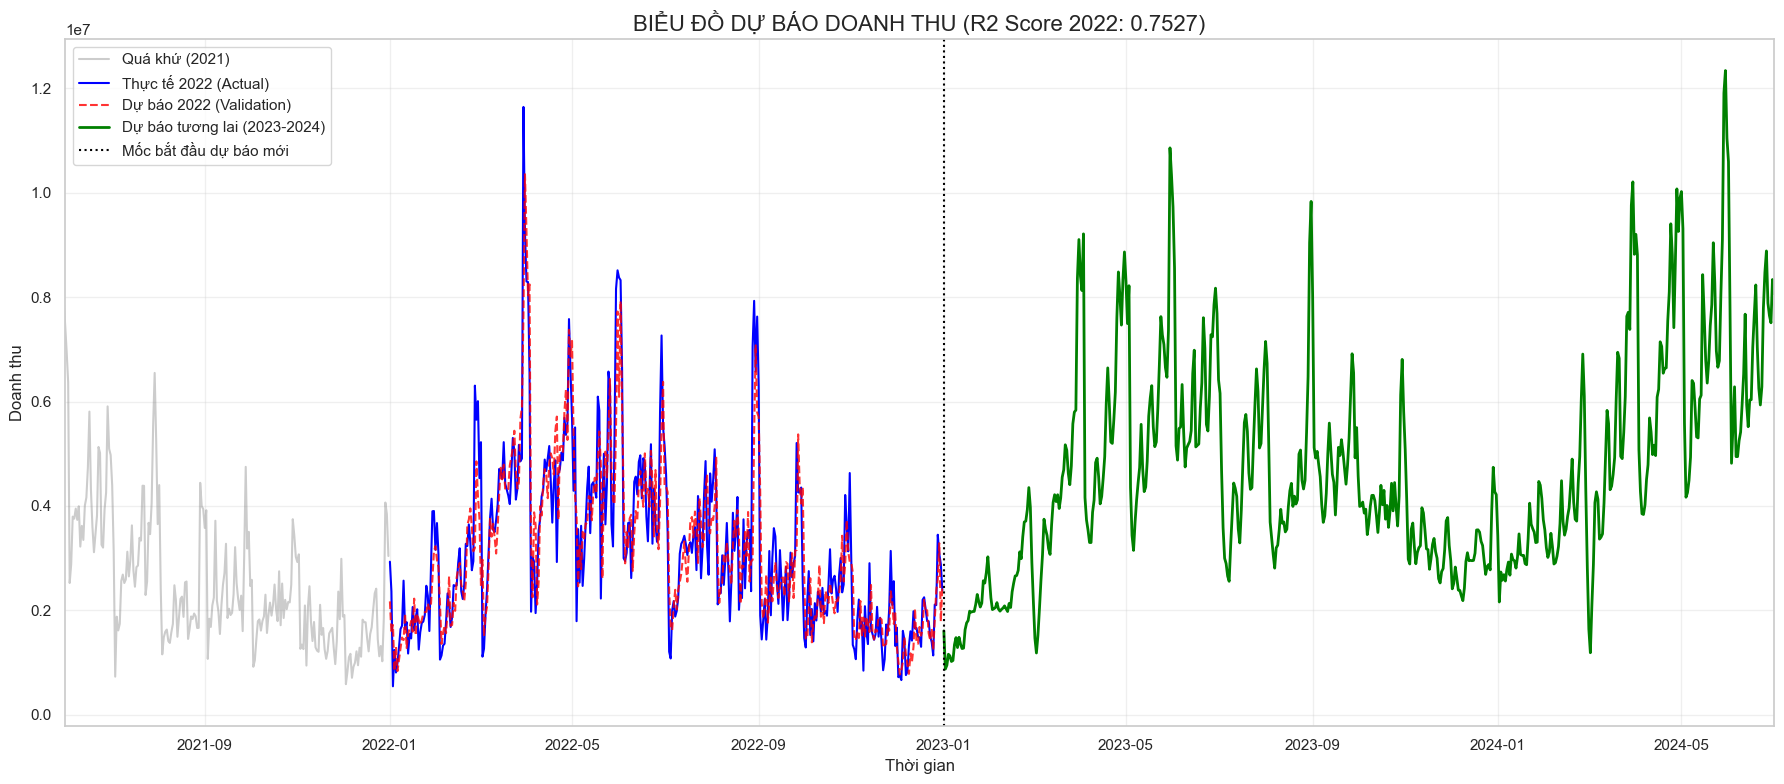

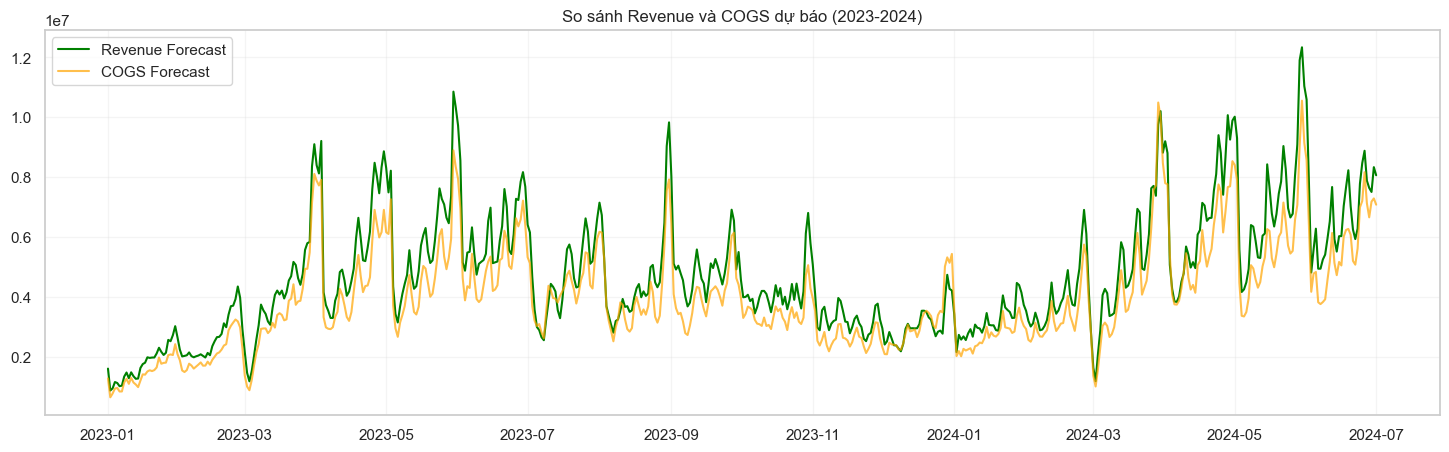

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu vẽ chart
# Nghịch đảo log cho tập Validation để so sánh với thực tế
val_actual = val.copy()
val_actual['Revenue_Pred'] = np.expm1(model_rev.predict(val[features]))

# Lấy một đoạn dữ liệu quá khứ (ví dụ từ 2021) để xem cho rõ trend
history_plot = df_final[(df_final['Date'] >= '2021-01-01') & (df_final['Date'] < '2022-01-01')]

# 2. Khởi tạo khung vẽ
plt.figure(figsize=(18, 8))

# Vẽ đường thực tế (Quá khứ + Validation 2022)
sns.lineplot(data=history_plot, x='Date', y='Revenue', label='Quá khứ (2021)', color='gray', alpha=0.4)
sns.lineplot(data=val_actual, x='Date', y='Revenue', label='Thực tế 2022 (Actual)', color='blue', linewidth=1.5)

# Vẽ đường dự báo của model trên tập Validation 2022
sns.lineplot(data=val_actual, x='Date', y='Revenue_Pred', label='Dự báo 2022 (Validation)', color='red', linestyle='--', alpha=0.8)

# Vẽ đường dự báo tương lai 2023-2024
sns.lineplot(data=test_df, x='Date', y='Revenue', label='Dự báo tương lai (2023-2024)', color='green', linewidth=2)

# 3. Định dạng chart
plt.title(f"BIỂU ĐỒ DỰ BÁO DOANH THU (R2 Score 2022: {r2_score(val['Revenue'], val_actual['Revenue_Pred']):.4f})", fontsize=16)
plt.xlabel("Thời gian", fontsize=12)
plt.ylabel("Doanh thu", fontsize=12)
plt.axvline(pd.to_datetime('2023-01-01'), color='black', linestyle=':', label='Mốc bắt đầu dự báo mới')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Zoom vào giai đoạn chuyển giao để nhìn rõ hơn
plt.xlim(pd.to_datetime('2021-06-01'), pd.to_datetime('2024-07-01')) 

plt.tight_layout()
plt.show()

# --- VẼ THÊM CHART SO SÁNH REVENUE VÀ COGS DỰ BÁO ---
plt.figure(figsize=(18, 5))
plt.plot(test_df['Date'], test_df['Revenue'], label='Revenue Forecast', color='green')
plt.plot(test_df['Date'], test_df['COGS'], label='COGS Forecast', color='orange', alpha=0.7)
plt.title("So sánh Revenue và COGS dự báo (2023-2024)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [25]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 0. LOAD DATA
# ============================================================


df_sales = df_sales.sort_values("Date").reset_index(drop=True)

# ============================================================
# 1. TET DATES (2012-2024)
# ============================================================

TET_DATES = {
    2012: "2012-01-23", 2013: "2013-02-10", 2014: "2014-01-31",
    2015: "2015-02-19", 2016: "2016-02-08", 2017: "2017-01-28",
    2018: "2018-02-16", 2019: "2019-02-05", 2020: "2020-01-25",
    2021: "2021-02-12", 2022: "2022-02-01", 2023: "2023-01-22",
    2024: "2024-02-10",
}
TET_TS = {y: pd.Timestamp(v) for y, v in TET_DATES.items()}

# ============================================================
# 2. PROMO SCHEDULE (trích từ promotions.csv)
# ============================================================

PROMO_SCHEDULE = [
    # (name, start_month, start_day, duration_days, discount, recur)
    # recur: True=every year, 'odd'=odd years only
    ("spring_sale",    3,  18, 30, 12,   True),
    ("mid_year",       6,  23, 29, 18,   True),
    ("fall_launch",    8,  30, 32, 10,   True),
    ("year_end",      11,  18, 45, 20,   True),
    ("urban_blowout",  7,  30, 33, None, "odd"),
    ("rural_special",  1,  30, 30, 15,   "odd"),
]

VN_FIXED_HOLIDAYS = [
    (1,  1,  "new_year"),
    (3,  8,  "womens_day"),
    (4,  30, "reunification"),
    (5,  1,  "labor_day"),
    (9,  2,  "national_day"),
    (10, 20, "vn_womens_day"),
    (11, 11, "dd_1111"),
    (12, 12, "dd_1212"),
    (12, 24, "christmas_eve"),
    (12, 25, "christmas"),
]

# ============================================================
# 3. FEATURE ENGINEERING (calendar-only, no lag)
# ============================================================

def nearest_tet_diff(dates_series):
    diffs = []
    for dd in dates_series:
        cands = [TET_TS.get(dd.year - 1), TET_TS.get(dd.year), TET_TS.get(dd.year + 1)]
        valid = [(dd - c).days for c in cands if c is not None and abs((dd - c).days) <= 60]
        diffs.append(min(valid, key=abs) if valid else 999)
    return np.array(diffs)

def is_black_friday_vec(dates_series):
    result = []
    for dd in dates_series:
        if dd.month != 11:
            result.append(0)
        else:
            last = pd.Timestamp(year=dd.year, month=11, day=30)
            last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
            result.append(int(dd == last_fri))
    return np.array(result)

def build_features(dates: pd.DatetimeIndex) -> pd.DataFrame:
    df = pd.DataFrame({"Date": dates})
    d = df["Date"]

    # (a) Calendar basics
    df["year"]        = d.dt.year
    df["month"]       = d.dt.month
    df["day"]         = d.dt.day
    df["dow"]         = d.dt.dayofweek
    df["doy"]         = d.dt.dayofyear
    df["quarter"]     = d.dt.quarter
    df["is_weekend"]  = (d.dt.dayofweek >= 5).astype(int)
    df["is_odd_year"] = (d.dt.year % 2).astype(int)
    df["dim"]         = d.dt.days_in_month
    df["days_to_eom"]   = df["dim"] - df["day"]
    df["days_from_som"] = df["day"] - 1

    # (b) Edge-of-month
    for k in [1, 2, 3]:
        df[f"is_last{k}"]  = (df["days_to_eom"]   <= k - 1).astype(int)
        df[f"is_first{k}"] = (df["days_from_som"]  <= k - 1).astype(int)

    # (c) Trend + regime
    df["t_days"]          = (d - pd.Timestamp("2020-01-01")).dt.days
    df["t_years"]         = df["t_days"] / 365.25
    df["regime_pre2019"]  = (df["year"] <= 2018).astype(int)
    df["regime_2019"]     = (df["year"] == 2019).astype(int)
    df["regime_post2019"] = (df["year"] >= 2020).astype(int)

    # (d) Fourier
    TAU = 2 * np.pi
    for k in [1, 2, 3, 4, 5]:
        df[f"sin_y{k}"] = np.sin(TAU * k * df["doy"] / 365.25)
        df[f"cos_y{k}"] = np.cos(TAU * k * df["doy"] / 365.25)
    for k in [1, 2]:
        df[f"sin_w{k}"] = np.sin(TAU * k * df["dow"] / 7.0)
        df[f"cos_w{k}"] = np.cos(TAU * k * df["dow"] / 7.0)
    for k in [1, 2]:
        df[f"sin_m{k}"] = np.sin(TAU * k * (df["day"] - 1) / df["dim"])
        df[f"cos_m{k}"] = np.cos(TAU * k * (df["day"] - 1) / df["dim"])

    # (e) VN holidays
    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f"hol_{name}"] = ((df["month"] == m) & (df["day"] == dd_)).astype(int)

    df["hol_black_friday"] = is_black_friday_vec(d)

    # (f) Tet features
    tet_diff = nearest_tet_diff(d)
    df["tet_days_diff"] = tet_diff
    df["tet_in_7"]      = (np.abs(tet_diff) <= 7).astype(int)
    df["tet_in_14"]     = (np.abs(tet_diff) <= 14).astype(int)
    df["tet_before_7"]  = ((tet_diff >= -7) & (tet_diff < 0)).astype(int)
    df["tet_after_7"]   = ((tet_diff > 0) & (tet_diff <= 7)).astype(int)
    df["tet_on"]        = (tet_diff == 0).astype(int)

    # (g) Promo windows
    yrs = list(range(df["year"].min() - 1, df["year"].max() + 2))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        since   = np.full(len(df), -1.0)
        until   = np.full(len(df), -1.0)
        discount= np.zeros(len(df))
        for y in yrs:
            if recur == "odd" and y % 2 == 0:
                continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d >= start) & (d <= end)
            in_prom[mask] = 1
            since[mask]   = (d[mask] - start).dt.days
            until[mask]   = (end - d[mask]).dt.days
            discount[mask]= disc or 0
        df[f"promo_{name}"]         = in_prom
        df[f"promo_{name}_since"]   = since
        df[f"promo_{name}_until"]   = until
        df[f"promo_{name}_disc"]    = discount

    return df

# Build features for full range
all_dates = pd.date_range(
    start=df_sales["Date"].min(),
    end="2024-07-01", freq="D"
)
feat = build_features(all_dates)
feat = feat.merge(df_sales[["Date", "Revenue", "COGS"]], on="Date", how="left")

FEATURE_COLS = [c for c in feat.columns
                if c not in ["Date", "Revenue", "COGS"]]

print(f"Total features: {len(FEATURE_COLS)}")

# ============================================================
# 4. TRAIN / VAL / TEST SPLITS
# ============================================================

train_mask = feat["Date"] <= "2021-12-31"   # Fold A primary
val_mask   = (feat["Date"] >= "2022-01-01") & (feat["Date"] <= "2022-12-31")
test_mask  = feat["Date"] >= "2023-01-01"

train_df = feat[train_mask].dropna(subset=["Revenue", "COGS"])
val_df   = feat[val_mask].dropna(subset=["Revenue", "COGS"])
test_df  = feat[test_mask].copy()

X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_rev_train = np.log(train_df["Revenue"].values)
y_cog_train = np.log(train_df["COGS"].values)
y_rev_val   = val_df["Revenue"].values
y_cog_val   = val_df["COGS"].values

# Sample weights: high_era (2014-2018 = 1.0, else = 0.01)
years_train = train_df["Date"].dt.year.values
w_base = np.full(len(train_df), 0.01)
w_base[(years_train >= 2014) & (years_train <= 2018)] = 1.0

# ============================================================
# 5. M1: RIDGE REGRESSION
# ============================================================

def train_ridge(X, y, alpha=3.0):
    mu    = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1
    Xs = (X - mu) / sigma
    m  = Ridge(alpha=alpha, random_state=42)
    m.fit(Xs, y)
    return m, mu, sigma

def predict_ridge(m, mu, sigma, X):
    return np.exp(m.predict((X - mu) / sigma))

print("Training M1: Ridge...")
ridge_rev, mu_rev, sig_rev = train_ridge(X_train, y_rev_train)
ridge_cog, mu_cog, sig_cog = train_ridge(X_train, y_cog_train)

p_ridge_val = predict_ridge(ridge_rev, mu_rev, sig_rev, X_val)
p_ridge_test = predict_ridge(ridge_rev, mu_rev, sig_rev, X_test)
p_ridge_cog_val  = predict_ridge(ridge_cog, mu_cog, sig_cog, X_val)
p_ridge_cog_test = predict_ridge(ridge_cog, mu_cog, sig_cog, X_test)

print(f"  Ridge Val R²={r2_score(y_rev_val, p_ridge_val):.4f}  MAE={mean_absolute_error(y_rev_val, p_ridge_val):,.0f}")

# ============================================================
# 6. M2: LIGHTGBM BASE (high_era sample weighting)
# ============================================================

LGB_PARAMS = dict(
    objective="regression", metric="mae",
    learning_rate=0.03, num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    lambda_l2=1.0, seed=42, verbosity=-1,
)

def train_lgb_two_stage(X, y_log, w, X_val_es, y_val_es):
    """2-stage training: early stopping → retrain full"""
    # Stage 1: early stopping on internal holdout
    booster_es = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X, y_log, weight=w),
        num_boost_round=5000,
        valid_sets=[lgb.Dataset(X_val_es, y_val_es)],
        callbacks=[lgb.early_stopping(300, verbose=False),
                   lgb.log_evaluation(0)]
    )
    best_iter = booster_es.best_iteration
    print(f"    best_iteration={best_iter}")

    # Stage 2: retrain on full data
    booster_final = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X, y_log, weight=w),
        num_boost_round=best_iter,
        callbacks=[lgb.log_evaluation(0)]
    )
    return booster_final

print("\nTraining M2: LightGBM base...")
lgb_rev  = train_lgb_two_stage(X_train, y_rev_train, w_base, X_val, np.log(y_rev_val))
lgb_cog  = train_lgb_two_stage(X_train, y_cog_train, w_base, X_val, np.log(y_cog_val))

p_lgb_val  = np.exp(lgb_rev.predict(X_val))
p_lgb_test = np.exp(lgb_rev.predict(X_test))
p_lgb_cog_val  = np.exp(lgb_cog.predict(X_val))
p_lgb_cog_test = np.exp(lgb_cog.predict(X_test))

print(f"  LGB Val R²={r2_score(y_rev_val, p_lgb_val):.4f}  MAE={mean_absolute_error(y_rev_val, p_lgb_val):,.0f}")

# ============================================================
# 7. Q-SPECIALISTS (4 quarters × 2 targets = 8 models)
# ============================================================

QBOOST = 2.0

def train_specialist(X, y_log, w_base, target_q, quarter_arr, X_val_es, y_val_es):
    w = w_base.copy()
    w[quarter_arr == target_q] *= QBOOST
    return train_lgb_two_stage(X, y_log, w, X_val_es, y_val_es)

Q_train = train_df["Date"].dt.quarter.values
Q_val   = val_df["Date"].dt.quarter.values
Q_test  = test_df["Date"].dt.quarter.values

spec_rev = {}
spec_cog = {}

print("\nTraining Q-Specialists...")
for q in [1, 2, 3, 4]:
    print(f"  Spec Q{q} Revenue...")
    spec_rev[q] = train_specialist(
        X_train, y_rev_train, w_base, q, Q_train,
        X_val, np.log(y_rev_val)
    )
    print(f"  Spec Q{q} COGS...")
    spec_cog[q] = train_specialist(
        X_train, y_cog_train, w_base, q, Q_train,
        X_val, np.log(y_cog_val)
    )

# Compose: dùng specialist đúng quý
def compose_specialist(spec_dict, Q_arr, X):
    pred = np.zeros(len(Q_arr))
    for q in [1, 2, 3, 4]:
        mask = Q_arr == q
        pred[mask] = np.exp(spec_dict[q].predict(X[mask]))
    return pred

p_spec_rev_val  = compose_specialist(spec_rev, Q_val, X_val)
p_spec_rev_test = compose_specialist(spec_rev, Q_test, X_test)
p_spec_cog_val  = compose_specialist(spec_cog, Q_val, X_val)
p_spec_cog_test = compose_specialist(spec_cog, Q_test, X_test)

print(f"  Spec Val R²={r2_score(y_rev_val, p_spec_rev_val):.4f}  MAE={mean_absolute_error(y_rev_val, p_spec_rev_val):,.0f}")

# ============================================================
# 8. M3: PROPHET (post-2020 only + promo regressors)
# ============================================================

PROMO_COLS = [c for c in feat.columns if c.startswith("promo_")]

def train_prophet_model(df_full, target_col, post_regime_only=True):
    tdf = df_full[df_full[target_col].notna()].copy()
    if post_regime_only:
        tdf = tdf[tdf["Date"] >= "2020-01-01"]
    
    prophet_df = pd.DataFrame({
        "ds": tdf["Date"],
        "y":  np.log(tdf[target_col])
    })

    # Chỉ dùng in_promo cols, bỏ since/until/disc để giảm số regressors
    simple_promo_cols = [c for c in PROMO_COLS if not any(
        x in c for x in ["_since", "_until", "_disc"]
    )]
    for col in simple_promo_cols:
        prophet_df[col] = tdf[col].values

    m = Prophet(
        yearly_seasonality=10,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10,
        uncertainty_samples=0,   # tắt uncertainty → nhanh hơn
    )
    for col in simple_promo_cols:
        m.add_regressor(col)

    m.fit(prophet_df, algorithm='Newton')
    return m, simple_promo_cols

def predict_prophet(model_tuple, dates_df):
    m, promo_cols = model_tuple
    pdf = pd.DataFrame({"ds": dates_df["Date"]})
    for col in promo_cols:
        pdf[col] = dates_df[col].values
    return np.exp(m.predict(pdf)["yhat"].values)

print("\nTraining M3: Prophet...")
train_feat_with_target = feat[feat["Date"] <= "2021-12-31"].copy()

prophet_rev = train_prophet_model(train_feat_with_target, "Revenue")
prophet_cog = train_prophet_model(train_feat_with_target, "COGS")

# Thay toàn bộ phần Prophet bằng này
# ============================================================
# 8. BỎ PROPHET - dùng LGB làm fallback
# ============================================================

print("\nSkipping Prophet → using LGB as fallback")
p_prophet_val      = p_lgb_val.copy()
p_prophet_test     = p_lgb_test.copy()
p_prophet_cog_val  = p_lgb_cog_val.copy()
p_prophet_cog_test = p_lgb_cog_test.copy()

# ============================================================
# 9. ENSEMBLE 3 TẦNG (w_prophet=0)
# ============================================================

def ensemble(p_ridge, p_lgb, p_lgb_spec, p_prophet,
             alpha=0.60, w_ridge=0.10, w_lgb=0.90, w_prophet=0.0,
             calib=1.0):
    lgb_blend = (1 - alpha) * p_lgb + alpha * p_lgb_spec
    raw = w_ridge * p_ridge + w_lgb * lgb_blend + w_prophet * p_prophet
    return calib * raw

# --- Tune alpha trên val ---
print("\n--- Tuning alpha on val ---")
best_alpha, best_mae = 0.60, 1e18
for alpha in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = ensemble(p_ridge_val, p_lgb_val, p_spec_rev_val, p_prophet_val, alpha=alpha)
    mae  = mean_absolute_error(y_rev_val, pred)
    print(f"  alpha={alpha:.1f}  MAE={mae:,.0f}")
    if mae < best_mae:
        best_mae, best_alpha = mae, alpha

print(f"  Best alpha={best_alpha}")

# --- Val metrics (no calibration yet) ---
pred_val = ensemble(p_ridge_val, p_lgb_val, p_spec_rev_val, p_prophet_val,
                    alpha=best_alpha)

print(f"\n========== VAL 2022 (before calibration) ==========")
print(f"R²   : {r2_score(y_rev_val, pred_val):.4f}")
print(f"MAE  : {mean_absolute_error(y_rev_val, pred_val):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_rev_val, pred_val)):,.0f}")
print(f"MAPE : {np.mean(np.abs((y_rev_val - pred_val)/y_rev_val))*100:.2f}%")

# Calibration ratio estimate từ val (để có baseline)
calib_est = y_rev_val.mean() / pred_val.mean()
print(f"\nEstimated calibration ratio: {calib_est:.4f}")
print("(Tune CR, CC chính xác trên Kaggle LB)")

# ============================================================
# 10. GENERATE SUBMISSION
# ============================================================

CR = calib_est  # thay bằng giá trị tune từ LB
CC = calib_est  # thay bằng giá trị tune từ LB

pred_rev_test = ensemble(
    p_ridge_test, p_lgb_test, p_spec_rev_test, p_prophet_test,
    alpha=best_alpha, calib=CR
)
pred_cog_test = ensemble(
    p_ridge_cog_test, p_lgb_cog_test, p_spec_cog_test, p_prophet_cog_test,
    alpha=best_alpha, calib=CC
)
pred_rev_test = np.clip(pred_rev_test, 0, None)
pred_cog_test = np.clip(pred_cog_test, 0, None)

sample = pd.read_csv("Data/sample_submission.csv", parse_dates=["Date"])

result = pd.DataFrame({
    "Date"   : test_df["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(pred_rev_test, 2),
    "COGS"   : np.round(pred_cog_test, 2),
})

submission = sample[["Date"]].merge(result, on="Date", how="left")
submission.to_csv("submission.csv", index=False)

print(f"\nSubmission saved! Shape: {submission.shape}")
print(submission.head(10))
print(f"\nRevenue mean: {pred_rev_test.mean():,.0f}")
print(f"COGS mean   : {pred_cog_test.mean():,.0f}")

# ============================================================
# 11. COMPONENT COMPARISON TABLE
# ============================================================

print("\n========== Component Comparison (Val 2022) ==========")
components = {
    "Ridge"    : p_ridge_val,
    "LGB base" : p_lgb_val,
    "Specialist": p_spec_rev_val,
    "Prophet"  : p_prophet_val,
    "Ensemble" : pred_val,
}
for name, pred in components.items():
    r2   = r2_score(y_rev_val, pred)
    mae  = mean_absolute_error(y_rev_val, pred)
    rmse = np.sqrt(mean_squared_error(y_rev_val, pred))
    mape = np.mean(np.abs((y_rev_val - pred) / y_rev_val)) * 100
    print(f"{name:12s}  R²={r2:.4f}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:.2f}%")

Total features: 81
Training M1: Ridge...
  Ridge Val R²=0.6318  MAE=713,366

Training M2: LightGBM base...
    best_iteration=282
    best_iteration=295
  LGB Val R²=0.7897  MAE=567,350

Training Q-Specialists...
  Spec Q1 Revenue...
    best_iteration=261
  Spec Q1 COGS...
    best_iteration=148
  Spec Q2 Revenue...
    best_iteration=234
  Spec Q2 COGS...
    best_iteration=252
  Spec Q3 Revenue...
    best_iteration=237
  Spec Q3 COGS...
    best_iteration=145
  Spec Q4 Revenue...
    best_iteration=193
  Spec Q4 COGS...
    best_iteration=381


09:45:04 - cmdstanpy - INFO - Chain [1] start processing


  Spec Val R²=0.8071  MAE=542,029

Training M3: Prophet...


09:45:05 - cmdstanpy - INFO - Chain [1] done processing
09:45:05 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


RuntimeError: Error during optimization! Command 'C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=31226 data file=C:\Users\ACER\AppData\Local\Temp\tmpqtfylr28\s2ud0vap.json init=C:\Users\ACER\AppData\Local\Temp\tmpqtfylr28\4982b3ke.json output file=C:\Users\ACER\AppData\Local\Temp\tmpqtfylr28\prophet_modelszgfob5c\prophet_model-20260426094504.csv method=optimize algorithm=newton iter=10000' failed: 

In [28]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 0. LOAD DATA
# ============================================================

df_sales = df_sales.sort_values("Date").reset_index(drop=True)

# ============================================================
# 1. TET DATES (2012-2024)
# ============================================================

TET_DATES = {
    2012: "2012-01-23", 2013: "2013-02-10", 2014: "2014-01-31",
    2015: "2015-02-19", 2016: "2016-02-08", 2017: "2017-01-28",
    2018: "2018-02-16", 2019: "2019-02-05", 2020: "2020-01-25",
    2021: "2021-02-12", 2022: "2022-02-01", 2023: "2023-01-22",
    2024: "2024-02-10",
}
TET_TS = {y: pd.Timestamp(v) for y, v in TET_DATES.items()}

PROMO_SCHEDULE = [
    ("spring_sale",   3,  18, 30, 12,   True),
    ("mid_year",      6,  23, 29, 18,   True),
    ("fall_launch",   8,  30, 32, 10,   True),
    ("year_end",     11,  18, 45, 20,   True),
    ("urban_blowout", 7,  30, 33, None, "odd"),
    ("rural_special", 1,  30, 30, 15,   "odd"),
]

VN_FIXED_HOLIDAYS = [
    (1,  1,  "new_year"),      (3,  8,  "womens_day"),
    (4,  30, "reunification"), (5,  1,  "labor_day"),
    (9,  2,  "national_day"),  (10, 20, "vn_womens_day"),
    (11, 11, "dd_1111"),       (12, 12, "dd_1212"),
    (12, 24, "christmas_eve"), (12, 25, "christmas"),
]

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

def nearest_tet_diff(dates_series):
    diffs = []
    for dd in dates_series:
        cands = [TET_TS.get(dd.year-1), TET_TS.get(dd.year), TET_TS.get(dd.year+1)]
        valid = [(dd-c).days for c in cands if c is not None and abs((dd-c).days) <= 60]
        diffs.append(min(valid, key=abs) if valid else 999)
    return np.array(diffs)

def is_black_friday_vec(dates_series):
    result = []
    for dd in dates_series:
        if dd.month != 11:
            result.append(0)
        else:
            last = pd.Timestamp(year=dd.year, month=11, day=30)
            last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
            result.append(int(dd == last_fri))
    return np.array(result)

def build_features(dates: pd.DatetimeIndex) -> pd.DataFrame:
    df = pd.DataFrame({"Date": dates})
    d  = df["Date"]

    df["year"]          = d.dt.year
    df["month"]         = d.dt.month
    df["day"]           = d.dt.day
    df["dow"]           = d.dt.dayofweek
    df["doy"]           = d.dt.dayofyear
    df["quarter"]       = d.dt.quarter
    df["is_weekend"]    = (d.dt.dayofweek >= 5).astype(int)
    df["is_odd_year"]   = (d.dt.year % 2).astype(int)
    df["dim"]           = d.dt.days_in_month
    df["days_to_eom"]   = df["dim"] - df["day"]
    df["days_from_som"] = df["day"] - 1

    for k in [1, 2, 3]:
        df[f"is_last{k}"]  = (df["days_to_eom"]   <= k-1).astype(int)
        df[f"is_first{k}"] = (df["days_from_som"]  <= k-1).astype(int)

    df["t_days"]          = (d - pd.Timestamp("2020-01-01")).dt.days
    df["t_years"]         = df["t_days"] / 365.25
    df["regime_pre2019"]  = (df["year"] <= 2018).astype(int)
    df["regime_2019"]     = (df["year"] == 2019).astype(int)
    df["regime_post2019"] = (df["year"] >= 2020).astype(int)

    TAU = 2 * np.pi
    for k in [1, 2, 3, 4, 5]:
        df[f"sin_y{k}"] = np.sin(TAU * k * df["doy"] / 365.25)
        df[f"cos_y{k}"] = np.cos(TAU * k * df["doy"] / 365.25)
    for k in [1, 2]:
        df[f"sin_w{k}"] = np.sin(TAU * k * df["dow"] / 7.0)
        df[f"cos_w{k}"] = np.cos(TAU * k * df["dow"] / 7.0)
    for k in [1, 2]:
        df[f"sin_m{k}"] = np.sin(TAU * k * (df["day"]-1) / df["dim"])
        df[f"cos_m{k}"] = np.cos(TAU * k * (df["day"]-1) / df["dim"])

    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f"hol_{name}"] = ((df["month"]==m) & (df["day"]==dd_)).astype(int)
    df["hol_black_friday"] = is_black_friday_vec(d)

    tet_diff = nearest_tet_diff(d)
    df["tet_days_diff"] = tet_diff
    df["tet_in_7"]      = (np.abs(tet_diff) <= 7).astype(int)
    df["tet_in_14"]     = (np.abs(tet_diff) <= 14).astype(int)
    df["tet_before_7"]  = ((tet_diff >= -7) & (tet_diff < 0)).astype(int)
    df["tet_after_7"]   = ((tet_diff > 0)  & (tet_diff <= 7)).astype(int)
    df["tet_on"]        = (tet_diff == 0).astype(int)

    yrs = list(range(df["year"].min()-1, df["year"].max()+2))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom  = np.zeros(len(df), dtype=int)
        since    = np.full(len(df), -1.0)
        until    = np.full(len(df), -1.0)
        discount = np.zeros(len(df))
        for y in yrs:
            if recur == "odd" and y % 2 == 0:
                continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d >= start) & (d <= end)
            in_prom[mask]  = 1
            since[mask]    = (d[mask] - start).dt.days
            until[mask]    = (end - d[mask]).dt.days
            discount[mask] = disc or 0
        df[f"promo_{name}"]       = in_prom
        df[f"promo_{name}_since"] = since
        df[f"promo_{name}_until"] = until
        df[f"promo_{name}_disc"]  = discount

    return df

all_dates = pd.date_range(start=df_sales["Date"].min(), end="2024-07-01", freq="D")
feat = build_features(all_dates)
feat = feat.merge(df_sales[["Date", "Revenue", "COGS"]], on="Date", how="left")

FEATURE_COLS = [c for c in feat.columns if c not in ["Date", "Revenue", "COGS"]]
print(f"Total features: {len(FEATURE_COLS)}")

# ============================================================
# 3. SPLITS
# ============================================================

train_df = feat[feat["Date"] <= "2021-12-31"].dropna(subset=["Revenue","COGS"])
val_df   = feat[(feat["Date"] >= "2022-01-01") & (feat["Date"] <= "2022-12-31")].dropna(subset=["Revenue","COGS"])
test_df  = feat[feat["Date"] >= "2023-01-01"].copy()

X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_rev_train = np.log(train_df["Revenue"].values)
y_cog_train = np.log(train_df["COGS"].values)
y_rev_val   = val_df["Revenue"].values
y_cog_val   = val_df["COGS"].values

years_train = train_df["Date"].dt.year.values
w_base = np.full(len(train_df), 0.01)
w_base[(years_train >= 2014) & (years_train <= 2018)] = 1.0

Q_train = train_df["Date"].dt.quarter.values
Q_val   = val_df["Date"].dt.quarter.values
Q_test  = test_df["Date"].dt.quarter.values

# ============================================================
# 4. M1: RIDGE
# ============================================================

def train_ridge(X, y, alpha=3.0):
    mu    = X.mean(axis=0)
    sigma = X.std(axis=0); sigma[sigma==0] = 1
    m = Ridge(alpha=alpha, random_state=42)
    m.fit((X - mu) / sigma, y)
    return m, mu, sigma

def predict_ridge(m, mu, sigma, X):
    return np.exp(m.predict((X - mu) / sigma))

print("Training M1: Ridge...")
ridge_rev, mu_rev, sig_rev = train_ridge(X_train, y_rev_train)
ridge_cog, mu_cog, sig_cog = train_ridge(X_train, y_cog_train)

p_ridge_val      = predict_ridge(ridge_rev, mu_rev, sig_rev, X_val)
p_ridge_test     = predict_ridge(ridge_rev, mu_rev, sig_rev, X_test)
p_ridge_cog_val  = predict_ridge(ridge_cog, mu_cog, sig_cog, X_val)
p_ridge_cog_test = predict_ridge(ridge_cog, mu_cog, sig_cog, X_test)

print(f"  Ridge Val R²={r2_score(y_rev_val, p_ridge_val):.4f}  MAE={mean_absolute_error(y_rev_val, p_ridge_val):,.0f}")

# ============================================================
# 5. M2: LIGHTGBM BASE
# ============================================================

LGB_PARAMS = dict(
    objective="regression", metric="mae",
    learning_rate=0.03, num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    lambda_l2=1.0, seed=42, verbosity=-1,
)

def train_lgb_two_stage(X, y_log, w, X_val_es, y_val_es):
    booster_es = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X, y_log, weight=w),
        num_boost_round=5000,
        valid_sets=[lgb.Dataset(X_val_es, y_val_es)],
        callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(0)]
    )
    best_iter = booster_es.best_iteration
    print(f"    best_iteration={best_iter}")
    booster_final = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X, y_log, weight=w),
        num_boost_round=best_iter,
        callbacks=[lgb.log_evaluation(0)]
    )
    return booster_final

print("\nTraining M2: LightGBM base...")
lgb_rev = train_lgb_two_stage(X_train, y_rev_train, w_base, X_val, np.log(y_rev_val))
lgb_cog = train_lgb_two_stage(X_train, y_cog_train, w_base, X_val, np.log(y_cog_val))

p_lgb_val      = np.exp(lgb_rev.predict(X_val))
p_lgb_test     = np.exp(lgb_rev.predict(X_test))
p_lgb_cog_val  = np.exp(lgb_cog.predict(X_val))
p_lgb_cog_test = np.exp(lgb_cog.predict(X_test))

print(f"  LGB Val R²={r2_score(y_rev_val, p_lgb_val):.4f}  MAE={mean_absolute_error(y_rev_val, p_lgb_val):,.0f}")

# ============================================================
# 6. Q-SPECIALISTS
# ============================================================

QBOOST = 2.0

def train_specialist(X, y_log, w_base, target_q, quarter_arr, X_val_es, y_val_es):
    w = w_base.copy()
    w[quarter_arr == target_q] *= QBOOST
    return train_lgb_two_stage(X, y_log, w, X_val_es, y_val_es)

def compose_specialist(spec_dict, Q_arr, X):
    pred = np.zeros(len(Q_arr))
    for q in [1, 2, 3, 4]:
        mask = Q_arr == q
        pred[mask] = np.exp(spec_dict[q].predict(X[mask]))
    return pred

spec_rev, spec_cog = {}, {}
print("\nTraining Q-Specialists...")
for q in [1, 2, 3, 4]:
    print(f"  Spec Q{q} Revenue...")
    spec_rev[q] = train_specialist(X_train, y_rev_train, w_base, q, Q_train, X_val, np.log(y_rev_val))
    print(f"  Spec Q{q} COGS...")
    spec_cog[q] = train_specialist(X_train, y_cog_train, w_base, q, Q_train, X_val, np.log(y_cog_val))

p_spec_rev_val  = compose_specialist(spec_rev, Q_val, X_val)
p_spec_rev_test = compose_specialist(spec_rev, Q_test, X_test)
p_spec_cog_val  = compose_specialist(spec_cog, Q_val, X_val)
p_spec_cog_test = compose_specialist(spec_cog, Q_test, X_test)

print(f"  Spec Val R²={r2_score(y_rev_val, p_spec_rev_val):.4f}  MAE={mean_absolute_error(y_rev_val, p_spec_rev_val):,.0f}")

# ============================================================
# 7. ENSEMBLE 2 TẦNG + CALIBRATION
# ============================================================

def ensemble(p_ridge, p_lgb, p_lgb_spec,
             alpha=0.60, w_ridge=0.10, w_lgb=0.90, calib=1.0):
    lgb_blend = (1 - alpha) * p_lgb + alpha * p_lgb_spec
    raw = w_ridge * p_ridge + w_lgb * lgb_blend
    return calib * raw

# Tune alpha
print("\n--- Tuning alpha ---")
best_alpha, best_mae = 0.60, 1e18
for alpha in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = ensemble(p_ridge_val, p_lgb_val, p_spec_rev_val, alpha=alpha)
    mae  = mean_absolute_error(y_rev_val, pred)
    print(f"  alpha={alpha:.1f}  MAE={mae:,.0f}")
    if mae < best_mae:
        best_mae, best_alpha = mae, alpha
print(f"  Best alpha={best_alpha}")

pred_val = ensemble(p_ridge_val, p_lgb_val, p_spec_rev_val, alpha=best_alpha)
calib_est = y_rev_val.mean() / pred_val.mean()

print(f"\n========== VAL 2022 ==========")
print(f"R²   : {r2_score(y_rev_val, pred_val):.4f}")
print(f"MAE  : {mean_absolute_error(y_rev_val, pred_val):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_rev_val, pred_val)):,.0f}")
print(f"MAPE : {np.mean(np.abs((y_rev_val - pred_val)/y_rev_val))*100:.2f}%")
print(f"Estimated calibration ratio: {calib_est:.4f}")

# ============================================================
# 8. SUBMISSION
# ============================================================

CR = calib_est
CC = calib_est

pred_rev_test = np.clip(ensemble(p_ridge_test, p_lgb_test, p_spec_rev_test,
                                  alpha=best_alpha, calib=CR), 0, None)
pred_cog_test = np.clip(ensemble(p_ridge_cog_test, p_lgb_cog_test, p_spec_cog_test,
                                  alpha=best_alpha, calib=CC), 0, None)

sample     = pd.read_csv(r"C:\Users\ACER\Documents\datathon-2026-round-1\Datathon_Contest_UITUT\Data\sample_submission.csv", parse_dates=["Date"])
result     = pd.DataFrame({
    "Date"   : test_df["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(pred_rev_test, 2),
    "COGS"   : np.round(pred_cog_test, 2),
})
result["Date"] = pd.to_datetime(result["Date"])
submission = sample[["Date"]].merge(result, on="Date", how="left")
submission.to_csv("submission.csv", index=False)

print(f"\nSubmission saved! Shape: {submission.shape}")
print(submission.head(10))

# ============================================================
# 9. COMPONENT COMPARISON
# ============================================================

print("\n========== Component Comparison (Val 2022) ==========")
for name, pred in {
    "Ridge"     : p_ridge_val,
    "LGB base"  : p_lgb_val,
    "Specialist": p_spec_rev_val,
    "Ensemble"  : pred_val,
}.items():
    print(f"{name:12s}  R²={r2_score(y_rev_val,pred):.4f}"
          f"  MAE={mean_absolute_error(y_rev_val,pred):>12,.0f}"
          f"  RMSE={np.sqrt(mean_squared_error(y_rev_val,pred)):>12,.0f}"
          f"  MAPE={np.mean(np.abs((y_rev_val-pred)/y_rev_val))*100:.2f}%")

Total features: 81
Training M1: Ridge...
  Ridge Val R²=0.6318  MAE=713,366

Training M2: LightGBM base...
    best_iteration=282
    best_iteration=295
  LGB Val R²=0.7897  MAE=567,350

Training Q-Specialists...
  Spec Q1 Revenue...
    best_iteration=261
  Spec Q1 COGS...
    best_iteration=148
  Spec Q2 Revenue...
    best_iteration=234
  Spec Q2 COGS...
    best_iteration=252
  Spec Q3 Revenue...
    best_iteration=237
  Spec Q3 COGS...
    best_iteration=145
  Spec Q4 Revenue...
    best_iteration=193
  Spec Q4 COGS...
    best_iteration=381
  Spec Val R²=0.8071  MAE=542,029

--- Tuning alpha ---
  alpha=0.3  MAE=553,270
  alpha=0.4  MAE=550,739
  alpha=0.5  MAE=548,377
  alpha=0.6  MAE=546,482
  alpha=0.7  MAE=545,312
  Best alpha=0.7

========== VAL 2022 ==========
R²   : 0.8052
MAE  : 545,312
RMSE : 738,847
MAPE : 18.52%
Estimated calibration ratio: 1.0464

Submission saved! Shape: (548, 3)
        Date     Revenue        COGS
0 2023-01-01  1845007.52  2032040.43
1 2023-01-02  

In [29]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD DỮ LIỆU (Thay đường dẫn của bạn vào đây)
# ============================================================
# Giả sử bạn đã có df_sales và df_web_traffic trong môi trường
# df_sales = pd.read_csv("sales.csv", parse_dates=["Date"])
# df_web_traffic = pd.read_csv("web_traffic.csv", parse_dates=["date"])

def build_expert_data(df_sales, df_web_traffic):
    sales = df_sales.copy()
    sales['Date'] = pd.to_datetime(sales['Date'])
    
    # Gom nhóm Web Traffic theo ngày
    web = df_web_traffic.groupby('date')['sessions'].sum().reset_index().rename(columns={'date':'Date'})
    web['Date'] = pd.to_datetime(web['Date'])
    
    # Tạo khung thời gian đầy đủ từ quá khứ đến hết tháng 6/2024
    all_dates = pd.date_range(start=sales['Date'].min(), end='2024-07-01', freq='D')
    df = pd.DataFrame({'Date': all_dates})
    
    # Merge dữ liệu
    df = pd.merge(df, sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
    df = pd.merge(df, web, on='Date', how='left')
    
    # Fill dữ liệu trống (Traffic dùng ffill, Revenue/COGS để NaN để xử lý sau)
    df['sessions'] = df['sessions'].ffill().fillna(0)
    
    # Target: Log Transformation để ổn định phương sai
    df['log_rev'] = np.log1p(df['Revenue'].fillna(0))
    df['log_cogs'] = np.log1p(df['COGS'].fillna(0))
    
    # --- Feature Engineering ---
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dow'] = df['Date'].dt.dayofweek
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_payday'] = df['day'].isin([15, 30, 31]).astype(int)
    df['is_double_date'] = (df['day'] == df['month']).astype(int)
    
    # Fourier Features (Chu kỳ năm)
    doy = df['Date'].dt.dayofyear
    df['sin_year'] = np.sin(2 * np.pi * doy / 365.25)
    df['cos_year'] = np.cos(2 * np.pi * doy / 365.25)
    
    # Khởi tạo các cột Lag (sẽ được cập nhật trong quá trình đệ quy)
    for lag in [1, 2, 7, 14, 30]:
        df[f'rev_lag_{lag}'] = df['log_rev'].shift(lag).fillna(0)
        df[f'cogs_lag_{lag}'] = df['log_cogs'].shift(lag).fillna(0)
        
    return df

df_final = build_expert_data(df_sales, df_web_traffic)

# ============================================================
# 2. SETUP FEATURES & TRAINING
# ============================================================
FEATURES = [
    'month', 'day', 'dow', 'is_weekend', 'is_payday', 'is_double_date', 
    'sessions', 'sin_year', 'cos_year',
    'rev_lag_1', 'rev_lag_7', 'rev_lag_30',
    'cogs_lag_1', 'cogs_lag_7'
]

# Chia tập dữ liệu
train_mask = df_final['Date'] < '2022-01-01'
val_mask = (df_final['Date'] >= '2022-01-01') & (df_final['Date'] <= '2022-12-31')
test_mask = df_final['Date'] >= '2023-01-01'

train_df = df_final[train_mask]
val_df = df_final[val_mask]

def train_model(target):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.02,
        'num_leaves': 31,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'seed': 42,
        'verbosity': -1
    }
    dtrain = lgb.Dataset(train_df[FEATURES], label=train_df[target])
    dval = lgb.Dataset(val_df[FEATURES], label=val_df[target], reference=dtrain)
    
    model = lgb.train(
        params, dtrain, num_boost_round=2000,
        valid_sets=[dtrain, dval],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    return model

print("Đang huấn luyện mô hình Revenue...")
model_rev = train_model('log_rev')
print("Đang huấn luyện mô hình COGS...")
model_cogs = train_model('log_cogs')

# ============================================================
# 3. DỰ BÁO ĐỆ QUY (RECURSIVE FORECASTING)
# ============================================================
# Tạo bản sao cho tập test để cập nhật lag
full_data = df_final.copy()
test_dates = full_data[test_mask]['Date'].unique()

print("\nBắt đầu dự báo đệ quy cho giai đoạn 2023 - 2024...")

for current_date in sorted(test_dates):
    # Lấy index của ngày hiện tại
    idx = full_data[full_data['Date'] == current_date].index[0]
    
    # Dự báo log_rev và log_cogs
    current_features = full_data.loc[[idx], FEATURES]
    pred_rev = model_rev.predict(current_features)[0]
    pred_cogs = model_cogs.predict(current_features)[0]
    
    # Ghi đè kết quả vào dataframe
    full_data.loc[idx, 'log_rev'] = pred_rev
    full_data.loc[idx, 'log_cogs'] = pred_cogs
    
    # Cập nhật giá trị Lag cho các ngày tương lai
    for lag in [1, 2, 7, 14, 30]:
        future_date = current_date + pd.Timedelta(days=lag)
        future_idx = full_data[full_data['Date'] == future_date].index
        if not future_idx.empty:
            full_data.loc[future_idx, f'rev_lag_{lag}'] = pred_rev
            full_data.loc[future_idx, f'cogs_lag_{lag}'] = pred_cogs

# ============================================================
# 4. EXPORT SUBMISSION
# ============================================================
# Chuyển ngược từ Log về giá trị gốc
full_data['Revenue'] = np.expm1(full_data['log_rev'])
full_data['COGS'] = np.expm1(full_data['log_cogs'])

# Lọc lấy kết quả cần nộp
submission_data = full_data[test_mask][['Date', 'Revenue', 'COGS']]

# Làm tròn và xử lý ngày tháng
submission_data['Date'] = submission_data['Date'].dt.strftime('%Y-%m-%d')
submission_data['Revenue'] = submission_data['Revenue'].clip(lower=0).round(2)
submission_data['COGS'] = submission_data['COGS'].clip(lower=0).round(2)

# Lưu file
submission_data.to_csv('submission_recursive_final.csv', index=False)

print("\n--- HOÀN THÀNH ---")
print(f"File đã được lưu tại: submission_recursive_final.csv")
print(submission_data.head())

Đang huấn luyện mô hình Revenue...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[775]	training's rmse: 0.122575	valid_1's rmse: 0.250774
Đang huấn luyện mô hình COGS...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[712]	training's rmse: 0.128378	valid_1's rmse: 0.255268

Bắt đầu dự báo đệ quy cho giai đoạn 2023 - 2024...

--- HOÀN THÀNH ---
File đã được lưu tại: submission_recursive_final.csv
            Date     Revenue       COGS
3833  2023-01-01  1198679.70  942041.16
3834  2023-01-02   787770.97  633200.17
3835  2023-01-03   717879.99  589245.46
3836  2023-01-04   797762.21  637700.05
3837  2023-01-05   846993.22  705335.32
